# IndoBERT + Nested BERTopic — iPusnas
## Pipeline Analisis Sentimen dengan Pendekatan Nested Topic Modeling

In [ ]:
!pip install -q bertopic sentence-transformers \
             umap-learn hdbscan transformers torch \
             scikit-learn pandas matplotlib seaborn emoji plotly google-play-scraper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.2 MB/s eta 0:00:00


In [ ]:
import os, re, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import emoji
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {device}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
print("Import selesai.")


Device   : cuda
CUDA     : True
GPU      : Tesla T4
Import selesai.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/skripsi/nested_bertopic'
MODEL_DIR  = '/content/drive/MyDrive/skripsi/analisis sentimen/models/indobert_balanced'
DATA_DIR   = '/content/drive/MyDrive/skripsi/analisis sentimen/dataset'
OUTPUT_DIR = f'{BASE_DIR}/output'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"BASE      : {BASE_DIR}")
print(f"MODEL     : {MODEL_DIR}")
print(f"DATA      : {DATA_DIR}")
print(f"OUTPUT    : {OUTPUT_DIR}")

Mounted at /content/drive
BASE      : /content/drive/MyDrive/skripsi/nested_bertopic
MODEL     : /content/drive/MyDrive/skripsi/analisis sentimen/models/indobert_balanced
DATA      : /content/drive/MyDrive/skripsi/analisis sentimen/dataset
OUTPUT    : /content/drive/MyDrive/skripsi/nested_bertopic/output


## Load & Preprocessing Dataset

In [ ]:
from google_play_scraper import reviews, Sort

RAW_FULL_PATH = f'{DATA_DIR}/dataset_ipusnas_raw_full.csv'

def scrape_all(app_id, target=45000, batch=200):
    all_rev = []
    token   = None
    print(f"Scraping '{app_id}' — target {target:,} ulasan")
    print("-" * 55)
    while len(all_rev) < target:
        try:
            result, token = reviews(
                app_id, lang='id', country='id',
                sort=Sort.NEWEST, count=batch,
                continuation_token=token
            )
            if not result:
                print(f"Tidak ada ulasan tersisa pada {len(all_rev):,}")
                break
            all_rev.extend(result)
            if len(all_rev) % 5000 < batch:
                oldest = all_rev[-1]['at'].strftime('%Y-%m-%d')
                print(f"  {len(all_rev):,} ulasan | terlama: {oldest}")
                pd.DataFrame(all_rev).to_csv(
                    f'{DATA_DIR}/scrape_temp.csv', index=False, encoding='utf-8-sig'
                )
            if not token:
                print(f"Semua ulasan habis: {len(all_rev):,}")
                break
            time.sleep(0.3)
        except Exception as e:
            print(f"Error: {e} — retry 10 detik...")
            time.sleep(10)
    return all_rev

if os.path.exists(RAW_FULL_PATH):
    print("File sudah ada — load dari Drive")
    df_raw = pd.read_csv(RAW_FULL_PATH, parse_dates=['at'])
else:
    raw    = scrape_all(APP_ID)
    df_raw = pd.DataFrame(raw)
    df_raw = df_raw.rename(columns={
        'content': 'ulasan', 'score': 'rating',
        'reviewCreatedVersion': 'appVersion'
    })
    df_raw['at'] = pd.to_datetime(df_raw['at'])
    df_raw = df_raw[['ulasan', 'rating', 'at', 'appVersion']].dropna(subset=['ulasan'])
    df_raw.to_csv(RAW_FULL_PATH, index=False, encoding='utf-8-sig')
    print(f"Disimpan ke: {RAW_FULL_PATH}")

print(f"\nTotal ulasan    : {len(df_raw):,}")
print(f"Rentang tanggal : {df_raw['at'].min().date()} s/d {df_raw['at'].max().date()}")
print("\nDistribusi per tahun:")
print(df_raw['at'].dt.year.value_counts().sort_index().to_string())

File sudah ada — load dari Drive

Total ulasan    : 20,645
Rentang tanggal : 2016-08-16 s/d 2026-06-11

Distribusi per tahun:
at
2016     118
2017     556
2018    1636
2019    2854
2020    2924
2021    2151
2022    1089
2023    1083
2024    2391
2025    3031
2026    2812


STATISTIK DESKRIPTIF DATASET
  Sumber data     : Google Play Store (iPusnas)
  ID Aplikasi     : mam.reader.ipusnas
  Total ulasan    : 20,645
  Rentang waktu   : 2016-08-16 s/d 2026-06-11
  Jumlah tahun    : 11 tahun
  Rating rata-rata: 2.82 / 5.0
  Rating median   : 3.0

Distribusi rating:
  Bintang 1 :  7,447  (36.1%)
  Bintang 2 :  2,493  (12.1%)
  Bintang 3 :  2,787  (13.5%)
  Bintang 4 :  2,143  (10.4%)
  Bintang 5 :  5,775  (28.0%)


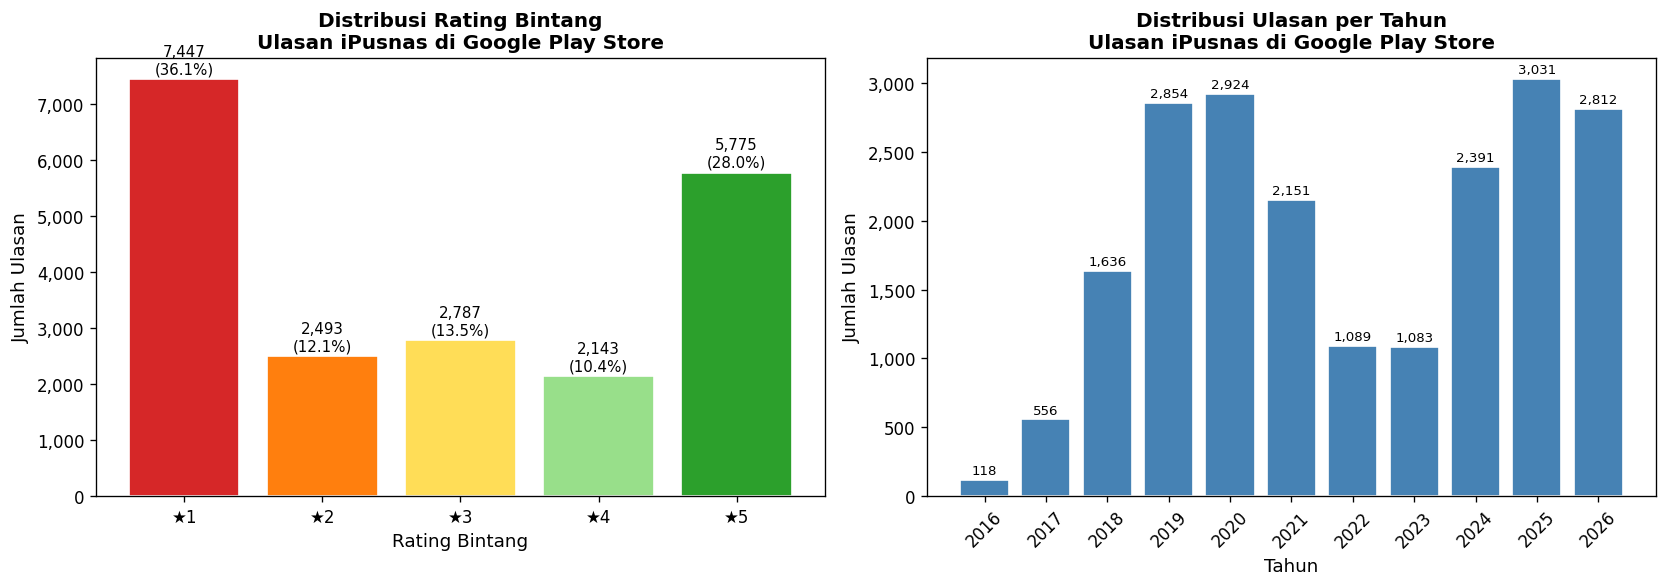


Gambar disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/distribusi_dataset.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

APP_ID = 'mam.reader.ipusnas'  # tambahkan ini

# ── 1. Statistik Deskriptif ───────────────────────────────────────────────────
print("=" * 55)
print("STATISTIK DESKRIPTIF DATASET")
print("=" * 55)
print(f"  Sumber data     : Google Play Store (iPusnas)")
print(f"  ID Aplikasi     : {APP_ID}")
print(f"  Total ulasan    : {len(df_raw):,}")
print(f"  Rentang waktu   : {df_raw['at'].min().date()} s/d {df_raw['at'].max().date()}")
print(f"  Jumlah tahun    : {df_raw['at'].dt.year.nunique()} tahun")
print(f"  Rating rata-rata: {df_raw['rating'].mean():.2f} / 5.0")
print(f"  Rating median   : {df_raw['rating'].median():.1f}")
print("=" * 55)
print("\nDistribusi rating:")
for r in [1, 2, 3, 4, 5]:
    n   = (df_raw['rating'] == r).sum()
    pct = n / len(df_raw) * 100
    print(f"  Bintang {r} : {n:>6,}  ({pct:.1f}%)")

# ── 2. Bar Chart Rating Bintang ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
rating_counts = df_raw['rating'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#98df8a', '#2ca02c']
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Rating Bintang', fontsize=11)
ax.set_ylabel('Jumlah Ulasan', fontsize=11)
ax.set_title('Distribusi Rating Bintang\nUlasan iPusnas di Google Play Store',
             fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['★1', '★2', '★3', '★4', '★5'])
for bar in bars:
    n   = int(bar.get_height())
    pct = n / len(df_raw) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{n:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── 3. Grafik Distribusi Ulasan per Tahun ────────────────────────────────────
ax2 = axes[1]
year_counts = df_raw['at'].dt.year.value_counts().sort_index()
bars2 = ax2.bar(year_counts.index, year_counts.values,
                color='steelblue', edgecolor='white')
ax2.set_xlabel('Tahun', fontsize=11)
ax2.set_ylabel('Jumlah Ulasan', fontsize=11)
ax2.set_title('Distribusi Ulasan per Tahun\nUlasan iPusnas di Google Play Store',
              fontweight='bold')
ax2.set_xticks(year_counts.index)
ax2.tick_params(axis='x', rotation=45)
for bar in bars2:
    n = int(bar.get_height())
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{n:,}', ha='center', va='bottom', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribusi_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nGambar disimpan: {OUTPUT_DIR}/distribusi_dataset.png")

In [ ]:
NORM_DICT = {
    'gk': 'tidak', 'ga': 'tidak', 'gak': 'tidak', 'gakk': 'tidak',
    'gabisa': 'tidak bisa', 'gbs': 'tidak bisa',
    'eror': 'error', 'ngelag': 'lag', 'lemottt': 'lemot',
    'apk': 'aplikasi', 'bgt': 'banget', 'tdk': 'tidak',
    'utk': 'untuk', 'yg': 'yang', 'dgn': 'dengan',
    'krn': 'karena', 'sdh': 'sudah', 'blm': 'belum',
    'msh': 'masih', 'hrs': 'harus', 'bs': 'bisa',
}

def preprocess(text):
    text = str(text).lower()
    text = emoji.replace_emoji(text, replace=' ')
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    for slang, formal in NORM_DICT.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', formal, text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

RAW_PATH = f'{DATA_DIR}/dataset_ipusnas_raw_full.csv'
print("Loading dataset...")
df_raw = pd.read_csv(RAW_PATH, parse_dates=['at'])
df_raw['cleaned'] = df_raw['ulasan'].apply(preprocess)
df_raw['n_words'] = df_raw['cleaned'].str.split().str.len()
df_valid = df_raw[df_raw['n_words'] >= 5].copy().reset_index(drop=True)
texts_clean = df_valid['cleaned'].tolist()

print(f"Total awal       : {len(df_raw):,}")
print(f"Valid (>=5 kata)  : {len(df_valid):,}")
print(f"Dihapus          : {len(df_raw) - len(df_valid):,}")
print(f"Rentang tanggal  : {df_valid['at'].min().date()} s/d {df_valid['at'].max().date()}")


Loading dataset...
Total awal       : 20,645
Valid (>=5 kata)  : 16,733
Dihapus          : 3,912
Rentang tanggal  : 2016-08-16 s/d 2026-06-11


Menghitung panjang token seluruh dataset...

STATISTIK TOKENISASI INDOBERT (max_length=128)
  Total ulasan        : 16,733
  Rata-rata token     : 25.0
  Median token        : 20.0
  Min token           : 7
  Max token           : 212
  Std deviasi         : 17.6
  Ulasan ter-truncate : 6 (0.04%)
  Ulasan aman (<=128) : 16,727 (100.0%)


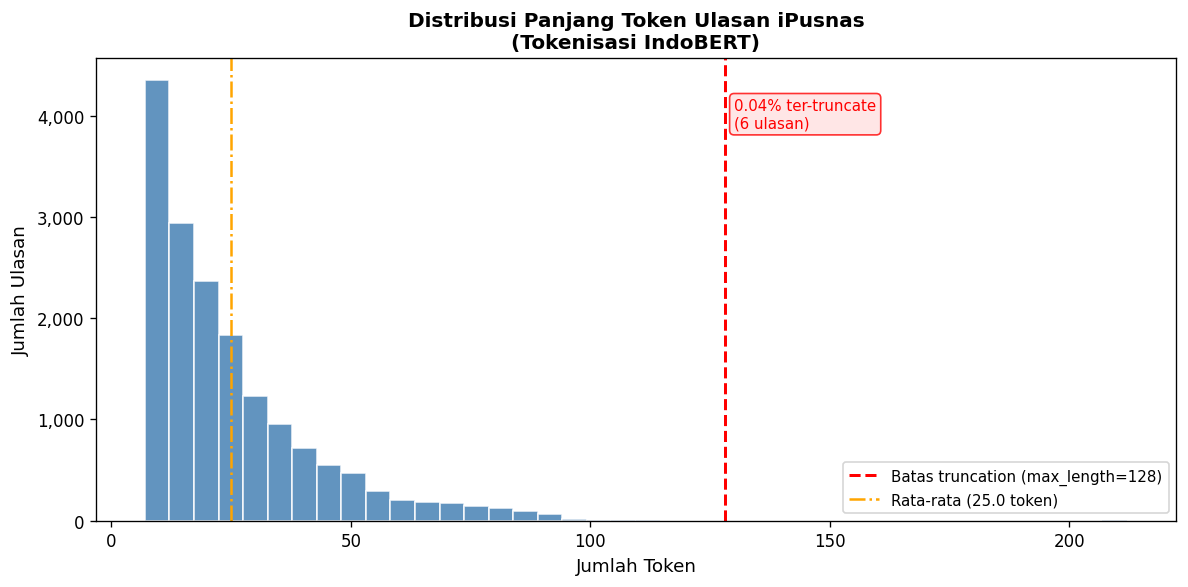

Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/distribusi_panjang_token.png

CONTOH ULASAN SEBELUM DAN SESUDAH PREPROCESSING

[1] Sebelum : Saya harap koleksi buku di ipusnas bertambah
    Sesudah : saya harap koleksi buku di ipusnas bertambah
    Token   : 11

[2] Sebelum : Sangat buruk, di perangkat saya versi terbaru ini tidak terbuka sama sekali, ipusnas seharusnya menj
    Sesudah : sangat buruk di perangkat saya versi terbaru ini tidak terbuka sama sekali ipusnas seharusnya menjad
    Token   : 31

[3] Sebelum : Suk banget sama Ipusnas, saya bisa baca banyak buku tentang Hacking,Networking,Pemrograman, dll, Ipu
    Sesudah : suk banget sama ipusnas saya bisa baca banyak buku tentang hacking networking pemrograman dll ipusna
    Token   : 24

[4] Sebelum : Kocak bener mau baca ae ngantri, mending app anybooks lah lebih bebas
    Sesudah : kocak bener mau baca ae ngantri mending app anybooks lah lebih bebas
    Token   : 17

[5] Sebelum : Setelah aplikasi di-update

In [ ]:
# ── Analisis Tokenisasi IndoBERT ──────────────────────────────────────────────
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

MAX_LENGTH = 128
tokenizer_analysis = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1')

print("Menghitung panjang token seluruh dataset...")
token_lengths = []
for text in texts_clean:  # texts_clean = df_valid['cleaned'].tolist()
    tokens = tokenizer_analysis.encode(text, add_special_tokens=True)
    token_lengths.append(len(tokens))

token_lengths = np.array(token_lengths)

# ── Statistik ─────────────────────────────────────────────────────────────────
n_truncated = (token_lengths > MAX_LENGTH).sum()
pct_truncated = n_truncated / len(token_lengths) * 100

print(f"\n{'='*55}")
print(f"STATISTIK TOKENISASI INDOBERT (max_length={MAX_LENGTH})")
print(f"{'='*55}")
print(f"  Total ulasan        : {len(token_lengths):,}")
print(f"  Rata-rata token     : {token_lengths.mean():.1f}")
print(f"  Median token        : {np.median(token_lengths):.1f}")
print(f"  Min token           : {token_lengths.min()}")
print(f"  Max token           : {token_lengths.max()}")
print(f"  Std deviasi         : {token_lengths.std():.1f}")
print(f"  Ulasan ter-truncate : {n_truncated:,} ({pct_truncated:.2f}%)")
print(f"  Ulasan aman (<={MAX_LENGTH}) : {len(token_lengths)-n_truncated:,} ({100-pct_truncated:.1f}%)")
print(f"{'='*55}")

# ── Histogram ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(token_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(MAX_LENGTH, color='red', linewidth=1.8, linestyle='--',
           label=f'Batas truncation (max_length={MAX_LENGTH})')
ax.axvline(token_lengths.mean(), color='orange', linewidth=1.5, linestyle='-.',
           label=f'Rata-rata ({token_lengths.mean():.1f} token)')

ax.set_xlabel('Jumlah Token', fontsize=11)
ax.set_ylabel('Jumlah Ulasan', fontsize=11)
ax.set_title('Distribusi Panjang Token Ulasan iPusnas\n(Tokenisasi IndoBERT)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Anotasi area truncated
ax.annotate(
    f'{pct_truncated:.2f}% ter-truncate\n({n_truncated:,} ulasan)',
    xy=(MAX_LENGTH + 2, ax.get_ylim()[1] * 0.85),
    fontsize=9, color='red',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe0e0', edgecolor='red', alpha=0.8)
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribusi_panjang_token.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Disimpan: {OUTPUT_DIR}/distribusi_panjang_token.png")

# ── Tabel Contoh Preprocessing ────────────────────────────────────────────────
print(f"\n{'='*80}")
print("CONTOH ULASAN SEBELUM DAN SESUDAH PREPROCESSING")
print(f"{'='*80}")

sample_idx = df_valid.sample(8, random_state=42).index
for i, idx in enumerate(sample_idx, 1):
    raw     = df_valid.loc[idx, 'ulasan']
    cleaned = df_valid.loc[idx, 'cleaned']
    n_tok   = token_lengths[df_valid.index.get_loc(idx)]
    print(f"\n[{i}] Sebelum : {str(raw)[:100]}")
    print(f"    Sesudah : {cleaned[:100]}")
    print(f"    Token   : {n_tok}")

## IndoBERT Sentiment Inference — Semua Ulasan

Mengikuti Iterasi 1 Alexander et al. (2022): klasifikasi sentimen dilakukan pada
**seluruh ulasan** sebelum pemisahan subkorpus.

Model IndoBERT di-load dari `best_model.pt` hasil fine-tuning sebelumnya.
Jika sudah ada `sentiment_full.csv` di Drive, hasil langsung di-load (skip inference).


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME  = 'indobenchmark/indobert-base-p1'
SAVED_MODEL = f'{MODEL_DIR}/best_model.pt'

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

if os.path.exists(SAVED_MODEL):
    bert_model.load_state_dict(torch.load(SAVED_MODEL, map_location=device))
    print(f"Model loaded: {SAVED_MODEL}")
else:
    print(f"WARNING: Model tidak ditemukan di {SAVED_MODEL}")
    print("Pastikan path MODEL_DIR sudah benar.")

bert_model.to(device)
bert_model.eval()
print(f"IndoBERT siap — device: {device}")


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: /content/drive/MyDrive/skripsi/analisis sentimen/models/indobert_balanced/best_model.pt
IndoBERT siap — device: cuda


In [ ]:
def batch_sentiment(texts, batch_size=64):
    labels, confs = [], []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, return_tensors='pt', truncation=True,
                        padding=True, max_length=128)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = bert_model(**enc).logits
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        conf_ = probs[range(len(batch)), preds]
        labels.extend(['positif' if p == 1 else 'negatif' for p in preds.cpu().tolist()])
        confs.extend([round(c, 4) for c in conf_.cpu().tolist()])
        if (i // batch_size + 1) % 100 == 0:
            print(f"  {min(i+batch_size, len(texts)):,} / {len(texts):,}...")
    return labels, confs

SENTIMENT_PATH = f'{OUTPUT_DIR}/sentiment_full.csv'

if os.path.exists(SENTIMENT_PATH):
    print("Sentimen sudah ada — load dari Drive")
    df_sent = pd.read_csv(SENTIMENT_PATH)
    df_valid['sentimen']   = df_sent['sentimen'].values
    df_valid['confidence'] = df_sent['confidence'].values
else:
    print(f"Inference sentimen {len(df_valid):,} ulasan...")
    print("Estimasi waktu dengan GPU: ~10-20 menit")
    lbl, conf = batch_sentiment(texts_clean)
    df_valid['sentimen']   = lbl
    df_valid['confidence'] = conf
    df_valid[['sentimen', 'confidence']].to_csv(SENTIMENT_PATH, index=False)
    print(f"Disimpan: {SENTIMENT_PATH}")

neg = (df_valid['sentimen'] == 'negatif').sum()
pos = (df_valid['sentimen'] == 'positif').sum()
total = len(df_valid)
print(f"\nDistribusi Sentimen:")
print(f"  Negatif : {neg:,}  ({neg/total*100:.1f}%)")
print(f"  Positif : {pos:,}  ({pos/total*100:.1f}%)")
print(f"  Total   : {total:,}")


Sentimen sudah ada — load dari Drive

Distribusi Sentimen:
  Negatif : 14,725  (88.0%)
  Positif : 2,008  (12.0%)
  Total   : 16,733


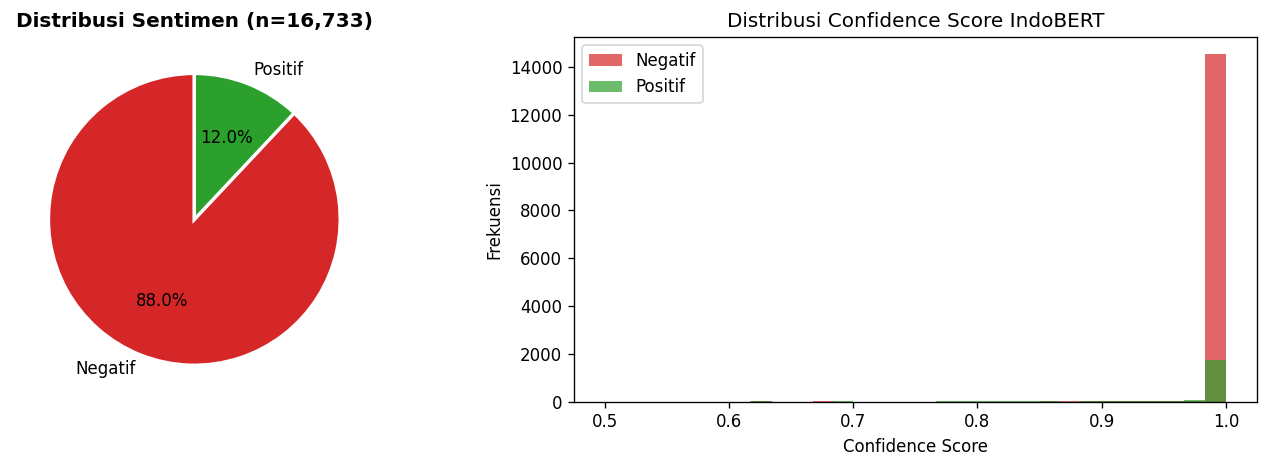

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
ax = axes[0]
neg = (df_valid['sentimen'] == 'negatif').sum()
pos = (df_valid['sentimen'] == 'positif').sum()
ax.pie([neg, pos], labels=['Negatif', 'Positif'],
       colors=['#d62728', '#2ca02c'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title(f'Distribusi Sentimen (n={neg+pos:,})', fontweight='bold')

# Confidence histogram
ax2 = axes[1]
ax2.hist(df_valid[df_valid['sentimen']=='negatif']['confidence'],
         bins=30, alpha=0.7, color='#d62728', label='Negatif')
ax2.hist(df_valid[df_valid['sentimen']=='positif']['confidence'],
         bins=30, alpha=0.7, color='#2ca02c', label='Positif')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Confidence Score IndoBERT')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()


## Split Subkorpus — Negatif & Positif

In [ ]:
df_neg = df_valid[df_valid['sentimen'] == 'negatif'].copy().reset_index(drop=True)
df_pos = df_valid[df_valid['sentimen'] == 'positif'].copy().reset_index(drop=True)

texts_neg = df_neg['cleaned'].tolist()
texts_pos = df_pos['cleaned'].tolist()

print(f"Subkorpus Negatif : {len(df_neg):,} ulasan  ({len(df_neg)/len(df_valid)*100:.1f}%)")
print(f"Subkorpus Positif : {len(df_pos):,} ulasan  ({len(df_pos)/len(df_valid)*100:.1f}%)")
print(f"Total             : {len(df_valid):,} ulasan")


Subkorpus Negatif : 14,725 ulasan  (88.0%)
Subkorpus Positif : 2,008 ulasan  (12.0%)
Total             : 16,733 ulasan


## BERTopic — Subkorpus Negatif (Topik Keluhan)


In [ ]:
# # FOR CPU

# from bertopic import BERTopic
# from sentence_transformers import SentenceTransformer
# from umap import UMAP
# from hdbscan import HDBSCAN
# from sklearn.feature_extraction.text import CountVectorizer

# STOPWORDS_ID = [
#     'yang', 'dan', 'di', 'ini', 'itu', 'untuk', 'dengan', 'dari', 'ke',
#     'adalah', 'ada', 'saya', 'tidak', 'juga', 'sudah', 'bisa', 'aja',
#     'nya', 'kali', 'jadi', 'nih', 'banget', 'sangat', 'sekali', 'lebih',
#     'belum', 'lagi', 'masih', 'mau', 'kalau', 'tapi', 'karena', 'pada',
#     'dalam', 'akan', 'atau', 'jika', 'saja', 'paling', 'kayak', 'udah',
#     'pas', 'buat', 'biasa', 'app', 'apps', 'ipusnas', 'perpusnas',
#     'aplikasi', 'bintang', 'star', 'rating',
# ]

# NEG_MODEL_PATH  = f'{OUTPUT_DIR}/bertopic_negatif'
# NEG_ASSIGN_PATH = f'{OUTPUT_DIR}/bertopic_negatif_assign.csv'

# embedding_model = SentenceTransformer(
#     'paraphrase-multilingual-MiniLM-L12-v2',
#     device='cuda' if torch.cuda.is_available() else 'cpu'
# )

# if os.path.exists(NEG_ASSIGN_PATH):
#     print("BERTopic Negatif sudah ada — load dari Drive")
#     df_assign_neg = pd.read_csv(NEG_ASSIGN_PATH)
#     df_neg['topic_id']    = df_assign_neg['topic_id'].values
#     df_neg['topic_label'] = df_assign_neg['topic_label'].values

#     _orig = torch.load
#     torch.load = lambda *args, **kwargs: _orig(
#         *args, **{**kwargs, 'map_location': torch.device('cpu')}
#     )
#     topic_model_neg = BERTopic.load(NEG_MODEL_PATH, embedding_model=embedding_model)
#     torch.load = _orig
#     print(f"Model loaded: {NEG_MODEL_PATH}")

# else:
#     print(f"Training BERTopic pada {len(texts_neg):,} ulasan negatif...")
#     print("Estimasi waktu: ~10-20 menit di Colab GPU")

#     umap_model = UMAP(
#         n_neighbors=15, n_components=5,
#         min_dist=0.0, metric='cosine', random_state=42
#     )
#     hdbscan_model = HDBSCAN(
#         min_cluster_size=20,
#         min_samples=5,
#         metric='euclidean',
#         cluster_selection_method='eom',
#         prediction_data=True
#     )
#     vectorizer_model = CountVectorizer(
#         ngram_range=(1, 2), stop_words=STOPWORDS_ID,
#         min_df=3, token_pattern=r'\b[a-z]{3,}\b'
#     )

#     topic_model_neg = BERTopic(
#         embedding_model=embedding_model,
#         umap_model=umap_model,
#         hdbscan_model=hdbscan_model,
#         vectorizer_model=vectorizer_model,
#         language='multilingual',
#         calculate_probabilities=False,
#         verbose=True,
#         nr_topics='auto'
#     )

#     topics_neg, _ = topic_model_neg.fit_transform(texts_neg)
#     df_neg['topic_id']    = topics_neg
#     df_neg['topic_label'] = [f'Topik {t}' if t != -1 else 'Noise' for t in topics_neg]

#     topic_model_neg.save(NEG_MODEL_PATH)
#     pd.DataFrame({'topic_id': topics_neg,
#                   'topic_label': df_neg['topic_label'].tolist()
#                   }).to_csv(NEG_ASSIGN_PATH, index=False)
#     print(f"Disimpan: {NEG_MODEL_PATH}")

# # Tampilkan ringkasan topik
# topic_info_neg = topic_model_neg.get_topic_info()
# topic_info_neg = topic_info_neg[topic_info_neg['Topic'] != -1].sort_values('Count', ascending=False)
# noise_n = len(df_neg[df_neg['topic_id'] == -1])

# print(f"\n{'='*68}")
# print(f"TOPIK KELUHAN DITEMUKAN: {len(topic_info_neg)}")
# print(f"Noise (tidak terkluster): {noise_n:,} ({noise_n/len(df_neg)*100:.1f}%)")
# print(f"{'='*68}")
# print(f"  {'ID':>4}  {'n':>6}  {'%':>5}  Keywords")
# print(f"  {'-'*60}")
# for _, row in topic_info_neg.iterrows():
#     tid  = int(row['Topic'])
#     n    = int(row['Count'])
#     pct  = n / len(df_neg) * 100
#     kws  = ', '.join([w for w, _ in topic_model_neg.get_topic(tid)[:6]])
#     print(f"  {tid:>4}  {n:>6}  {pct:>4.1f}%  {kws}")


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x7af9f0a43f60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
# FOR GPU

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

STOPWORDS_ID = [
    'yang', 'dan', 'di', 'ini', 'itu', 'untuk', 'dengan', 'dari', 'ke',
    'adalah', 'ada', 'saya', 'tidak', 'juga', 'sudah', 'bisa', 'aja',
    'nya', 'kali', 'jadi', 'nih', 'banget', 'sangat', 'sekali', 'lebih',
    'belum', 'lagi', 'masih', 'mau', 'kalau', 'tapi', 'karena', 'pada',
    'dalam', 'akan', 'atau', 'jika', 'saja', 'paling', 'kayak', 'udah',
    'pas', 'buat', 'biasa', 'app', 'apps', 'ipusnas', 'perpusnas',
    'aplikasi', 'bintang', 'star', 'rating',
]

NEG_MODEL_PATH  = f'{OUTPUT_DIR}/bertopic_negatif'
NEG_ASSIGN_PATH = f'{OUTPUT_DIR}/bertopic_negatif_assign.csv'

embedding_model = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2',
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

if os.path.exists(NEG_ASSIGN_PATH):
    print("BERTopic Negatif sudah ada — load dari Drive")
    df_assign_neg = pd.read_csv(NEG_ASSIGN_PATH)
    df_neg['topic_id']    = df_assign_neg['topic_id'].values
    df_neg['topic_label'] = df_assign_neg['topic_label'].values

    topic_model_neg = BERTopic.load(NEG_MODEL_PATH, embedding_model=embedding_model)
    print(f"Model loaded: {NEG_MODEL_PATH}")

else:
    print(f"Training BERTopic pada {len(texts_neg):,} ulasan negatif...")
    print("Estimasi waktu: ~10-20 menit di Colab GPU")

    umap_model = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.0, metric='cosine', random_state=42
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=20,   # tetap 20 agar sensitif
        min_samples=5,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )
    vectorizer_model = CountVectorizer(
        ngram_range=(1, 2), stop_words=STOPWORDS_ID,
        min_df=3, token_pattern=r'\b[a-z]{3,}\b'
    )

    topic_model_neg = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        language='multilingual',
        calculate_probabilities=False,
        verbose=True,
        nr_topics='auto'
    )

    topics_neg, _ = topic_model_neg.fit_transform(texts_neg)
    df_neg['topic_id']    = topics_neg
    df_neg['topic_label'] = [f'Topik {t}' if t != -1 else 'Noise' for t in topics_neg]

    topic_model_neg.save(NEG_MODEL_PATH)
    pd.DataFrame({'topic_id': topics_neg,
                  'topic_label': df_neg['topic_label'].tolist()
                  }).to_csv(NEG_ASSIGN_PATH, index=False)
    print(f"Disimpan: {NEG_MODEL_PATH}")

# Tampilkan ringkasan topik
topic_info_neg = topic_model_neg.get_topic_info()
topic_info_neg = topic_info_neg[topic_info_neg['Topic'] != -1].sort_values('Count', ascending=False)
noise_n = len(df_neg[df_neg['topic_id'] == -1])

print(f"\n{'='*68}")
print(f"TOPIK KELUHAN DITEMUKAN: {len(topic_info_neg)}")
print(f"Noise (tidak terkluster): {noise_n:,} ({noise_n/len(df_neg)*100:.1f}%)")
print(f"{'='*68}")
print(f"  {'ID':>4}  {'n':>6}  {'%':>5}  Keywords")
print(f"  {'-'*60}")
for _, row in topic_info_neg.iterrows():
    tid  = int(row['Topic'])
    n    = int(row['Count'])
    pct  = n / len(df_neg) * 100
    kws  = ', '.join([w for w, _ in topic_model_neg.get_topic(tid)[:6]])
    print(f"  {tid:>4}  {n:>6}  {pct:>4.1f}%  {kws}")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BERTopic Negatif sudah ada — load dari Drive
Model loaded: /content/drive/MyDrive/skripsi/nested_bertopic/output/bertopic_negatif

TOPIK KELUHAN DITEMUKAN: 85
Noise (tidak terkluster): 6,012 (40.8%)
    ID       n      %  Keywords
  ------------------------------------------------------------
     0     798   5.4%  pinjam, pinjam buku, buku, error, meminjam, meminjam buku
     1     583   4.0%  buku, membantu, fitur, bagus, saran, membaca
     2     466   3.2%  login, log, akun, log out, out, sendiri
     3     410   2.8%  update, setelah, setelah update, malah, makin, aplikasinya
     4     293   2.0%  download, download buku, didownload, download bukunya, bukunya, file
     5     275   1.9%  dibuka, buka, aplikasinya, aplikasinya dibuka, dibuka aplikasinya, aplikasinya buka
     6     266   1.8%  login, akun, log, buku, hilang, tiba
     7     250   1.7%  email, password, akun, verifikasi, login, verifikasi email
     8     228   1.5%  server, data server, mengambil, mengambil data, 

### Labeling Topik — Subkorpus Negatif


In [ ]:
# ── Eksplorasi ulasan per topik sebelum labeling ──────────────────────────────

TOPIC_ID = 0
N_SAMPLE = 10

df_explore = df_neg[df_neg['topic_id'] == TOPIC_ID].sample(
    min(N_SAMPLE, len(df_neg[df_neg['topic_id'] == TOPIC_ID])), random_state=42
)

kws = ', '.join([w for w, _ in topic_model_neg.get_topic(TOPIC_ID)[:8]])
print(f"Topik {TOPIC_ID} — Keywords: {kws}")
print(f"{'='*70}")
for i, row in df_explore.iterrows():
    print(f"  [{row['rating']}★] {row['ulasan'][:120]}")
    print()


Topik 0 — Keywords: pinjam, pinjam buku, buku, error, meminjam, meminjam buku, kenapa, aplikasinya
  [3★] Kenapa sekarang hanya bisa pinjam 2 buku saja?

  [2★] Koleksi bukunya lumayan banyak. Tapi sayang sekali sering error sehingga memperlambat pekerjaan saya.

  [1★] gak bisa pinjam buku padahal udah penasaran banget

  [4★] Mohon maaf, mengapa setiap saya meminjam buku di iPusnas loadingnya lama dan gagal terus. Mohon tanggapannya 🙏🙏 Terima k

  [2★] tidak bisa download buku sekarang ini ipusnas, selalu bermasalah Apps nya, beda dengan yang lalu-lalu; lancar

  [3★] Kenapa 3 hari ini aplikasi ipusnasku error terus. Tidak bisa dibuka, atau tidak bisa menampilkan buku. Padahal udah sene

  [1★] aplikasi tidak bisa di buka setelah update selalu keluar sendiri padahal hampir selesai baca buku "sejarah fisika dari C

  [1★] Terjadi kendala di android pd saat sdh pinjam buku dan mau membacanya tiba2 aplikasi keluar dgn sendirinya dan buku tdk 

  [3★] Kenapa masih belum bisa pinjam bukun

In [ ]:
NEG_TOPIC_LABELS = {
    -1: 'Noise',
     0: 'Error saat Meminjam Buku',
     1: 'Saran dan Apresiasi dengan Catatan',
     2: 'Auto Logout / Sesi Berakhir Sendiri',
     3: 'Aplikasi Makin Buruk Setelah Update',
     4: 'Gagal / Lambat Download Buku',
     5: 'Aplikasi Tidak Bisa Dibuka',
     6: 'Akun Hilang Tiba-tiba',
     7: 'Verifikasi Email/Password Bermasalah',
     8: 'Masalah Server DLS',
     9: 'Aplikasi Tidak Bisa Dibuka (varian 2)',
    10: 'Masalah Jaringan / Internet',
    11: 'Apresiasi Literasi Indonesia',
    12: 'Koleksi Buku Perlu Diperbanyak',
    13: 'Koleksi Buku Kurang Lengkap',
    14: 'Aplikasi Keluar / Force Close Sendiri',
    15: 'Susah Membaca Buku',
    16: 'Batas Waktu dan Kuota Peminjaman',
    17: 'Download Buku Tidak Masuk Perpustakaan',
    18: 'Update Menyebabkan Crash',
    19: 'Login Gagal Tanpa Sebab Jelas',
    20: 'Login via Facebook Bermasalah',
    21: 'Masalah Versi Aplikasi di Play Store',
    22: 'Email Verifikasi Tidak Masuk',
    23: 'Performa Memburuk Setelah Update',
    24: 'Banyak Bug / Butuh Maintenance',
    25: 'Apresiasi Aplikasi',
    26: 'Perbandingan dengan Perangkat Lain',
    27: 'Buku Tidak Bisa Diunduh',
    28: 'Error Berulang pada Aplikasi',
    29: 'Kritik Kualitas Aplikasi Pemerintah',
    30: 'Error Meski Menggunakan WiFi',
    31: 'Kritik Perpustakaan Nasional',
    32: 'Fitur Pencarian Bermasalah',
    33: 'Fitur Scroll, Bookmark, Highlight Bermasalah',
    34: 'Login Error Setelah Update',
    35: 'Sering Error',
    36: 'Force Close',
    37: 'Error Berulang (Varian)',
    38: 'Review Kondisional / Beri Bintang Dulu',
    39: 'Permintaan Fitur Beli Buku',
    40: 'Solusi Install Ulang Tidak Membantu',
    41: 'Login via Email Bermasalah',
    42: 'Sering Error saat Mendaftar',
    43: 'Fitur Bookmark Tidak Berfungsi',
    44: 'Error saat Meminjam (Varian)',
    45: 'Tidak Bisa Meminjam',
    46: 'Harapan Perbaikan ke Depan',
    47: 'Sering Error (Varian)',
    48: 'Lag / Aplikasi Lemot Parah',
    49: 'Masalah saat Mengirim Data ke Server',
    50: 'Permintaan Dark Mode',
    51: 'Susah Login / Auto Logout',
    52: 'Aplikasi Berhenti Sendiri',
    53: 'Tidak Bisa Masuk Akun',
    54: 'Tidak Support Tablet / Android Tertentu',
    55: 'Hasil Pencarian Tidak Akurat',
    56: 'Network Timeout',
    57: 'Loading Lama',
    58: 'Kurang Buku Akademik / Perkuliahan',
    59: 'Error Berlangsung Berhari-hari',
    60: 'Login Stuck / Harap Tunggu',
    61: 'Bug / Permintaan Perbaikan',
    62: 'Error Muncul Setelah Update',
    63: 'Tidak Ada Notifikasi Buku Tersedia',
    64: 'Antrian Peminjaman Terlalu Panjang',
    65: 'Kritik Kualitas Pemerintah (Varian)',
    66: 'Error Meski WiFi Lancar',
    67: 'Permintaan Perbaikan Fitur Pinjam',
    68: 'Server Sedang Maintenance',
    69: 'Ungkapan Frustrasi Umum',
    70: 'Durasi Peminjaman Terlalu Singkat',
    71: 'Bintang Kondisional',
    72: 'Verifikasi Email Selalu Gagal',
    73: 'Apresiasi saat Pandemi',
    74: 'Aplikasi Sering Error (Varian)',
    75: 'Permintaan Konten Keagamaan',
    76: 'Aksesibilitas untuk Tunanetra',
    77: 'Aplikasi Memenuhi Penyimpanan Internal',
    78: 'Loading Lama (Varian)',
    79: 'Ukuran Font Terlalu Kecil',
    80: 'Verifikasi Perangkat Gagal',
    81: 'Permintaan Perbaikan Segera',
    82: 'Tidak Support Landscape / Zoom',
    83: 'Aplikasi Sering Keluar Sendiri',
    84: 'Error saat Dibuka',
}



# ── Terapkan label ─────────────────────────────────────────────────────────────
if len(NEG_TOPIC_LABELS) > 1:  # hanya jika sudah diisi
    df_neg['topic_label'] = df_neg['topic_id'].map(NEG_TOPIC_LABELS).fillna(
        df_neg['topic_label']
    )

    # Update assignment CSV
    pd.DataFrame({'topic_id': df_neg['topic_id'].tolist(),
                  'topic_label': df_neg['topic_label'].tolist()
                  }).to_csv(NEG_ASSIGN_PATH, index=False)

    print("Label diperbarui.")
    print("\nDistribusi topik keluhan (subkorpus negatif):")
    print(f"  {'Label':<45} {'n':>6}  {'%':>5}")
    print(f"  {'-'*58}")
    dist = df_neg['topic_label'].value_counts()
    for label, n in dist.items():
        if label != 'Noise':
            print(f"  {label:<45} {n:>6}  {n/len(df_neg)*100:>4.1f}%")
else:
    print("Belum ada label yang diisi. Isi NEG_TOPIC_LABELS terlebih dahulu.")


Label diperbarui.

Distribusi topik keluhan (subkorpus negatif):
  Label                                              n      %
  ----------------------------------------------------------
  Error saat Meminjam Buku                         798   5.4%
  Saran dan Apresiasi dengan Catatan               583   4.0%
  Auto Logout / Sesi Berakhir Sendiri              466   3.2%
  Aplikasi Makin Buruk Setelah Update              410   2.8%
  Gagal / Lambat Download Buku                     293   2.0%
  Aplikasi Tidak Bisa Dibuka                       275   1.9%
  Akun Hilang Tiba-tiba                            266   1.8%
  Verifikasi Email/Password Bermasalah             250   1.7%
  Masalah Server DLS                               228   1.5%
  Aplikasi Tidak Bisa Dibuka (varian 2)            227   1.5%
  Masalah Jaringan / Internet                      207   1.4%
  Apresiasi Literasi Indonesia                     192   1.3%
  Koleksi Buku Perlu Diperbanyak                   182   1.2%
  Kole

TOP 15 TOPIK NEGATIF TERBESAR
    ID  Label Topik                                        n      %  Top Keywords
  ------------------------------------------------------------------------
     0  Error saat Meminjam Buku                         798   5.4%  pinjam, pinjam buku, buku, error
     1  Saran dan Apresiasi dengan Catatan               583   4.0%  buku, membantu, fitur, bagus
     2  Auto Logout / Sesi Berakhir Sendiri              466   3.2%  login, log, akun, log out
     3  Aplikasi Makin Buruk Setelah Update              410   2.8%  update, setelah, setelah update, malah
     4  Gagal / Lambat Download Buku                     293   2.0%  download, download buku, didownload, download bukunya
     5  Aplikasi Tidak Bisa Dibuka                       275   1.9%  dibuka, buka, aplikasinya, aplikasinya dibuka
     6  Akun Hilang Tiba-tiba                            266   1.8%  login, akun, log, buku
     7  Verifikasi Email/Password Bermasalah             250   1.7%  email, pass

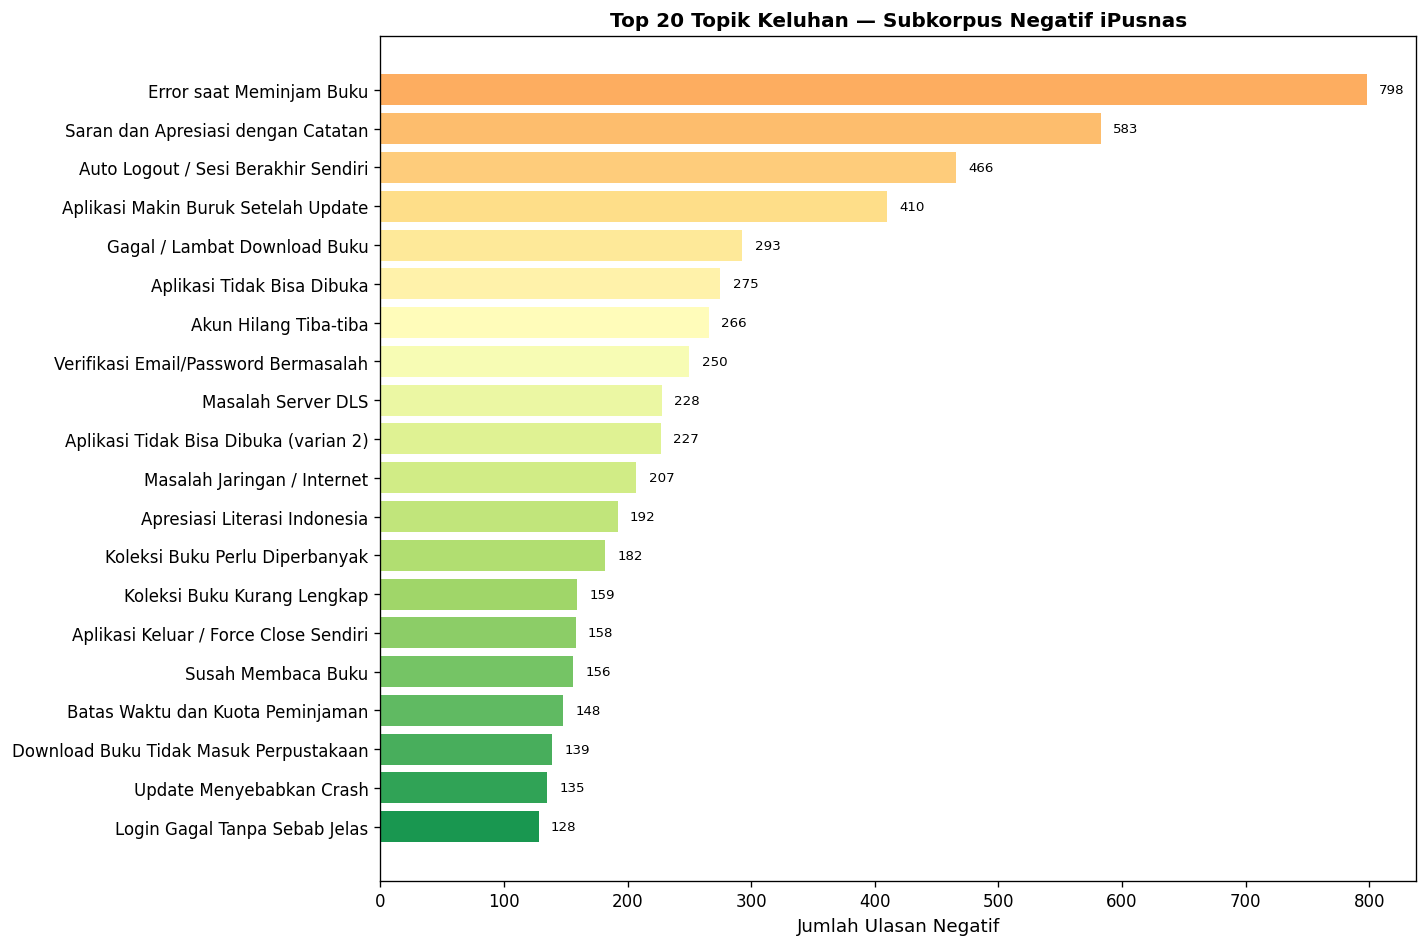

Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/top20_topik_negatif.png

Membuat UMAP scatter plot...


Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/umap_topik_negatif.html


Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/intertopic_distance_negatif.html


In [ ]:
# ── Tabel Top 15 Topik Negatif ────────────────────────────────────────────────
print("TOP 15 TOPIK NEGATIF TERBESAR")
print(f"{'='*72}")
print(f"  {'ID':>4}  {'Label Topik':<45} {'n':>6}  {'%':>5}  Top Keywords")
print(f"  {'-'*72}")
for _, row in topic_info_neg.head(15).iterrows():
    tid  = int(row['Topic'])
    n    = int(row['Count'])
    pct  = n / len(df_neg) * 100
    kws  = ', '.join([w for w, _ in topic_model_neg.get_topic(tid)[:4]])
    label = NEG_TOPIC_LABELS.get(tid, f'Topik {tid}')
    print(f"  {tid:>4}  {label:<45} {n:>6}  {pct:>4.1f}%  {kws}")

# ── Bar Chart Top 20 Topik Negatif ───────────────────────────────────────────
df_plot = topic_info_neg.head(20).copy()
df_plot['label'] = df_plot['Topic'].apply(
    lambda x: NEG_TOPIC_LABELS.get(int(x), f'Topik {x}')
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.7, len(df_plot)))
bars = ax.barh(df_plot['label'][::-1], df_plot['Count'][::-1], color=colors)
ax.set_xlabel('Jumlah Ulasan Negatif', fontsize=11)
ax.set_title('Top 20 Topik Keluhan — Subkorpus Negatif iPusnas',
             fontweight='bold', fontsize=12)
for bar in bars:
    n = int(bar.get_width())
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center', fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top20_topik_negatif.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Disimpan: {OUTPUT_DIR}/top20_topik_negatif.png")

# ── UMAP Scatter Plot ─────────────────────────────────────────────────────────
# print("\nMembuat UMAP scatter plot...")
# fig_umap = topic_model_neg.visualize_documents(
#     texts_neg,
#     title='UMAP Visualisasi Cluster Topik — Subkorpus Negatif iPusnas',
#     width=900,
#     height=600
# )
# fig_umap.write_html(f'{OUTPUT_DIR}/umap_topik_negatif.html')
# fig_umap.show()
# print(f"Disimpan: {OUTPUT_DIR}/umap_topik_negatif.html")

# # ── Intertopic Distance Map ───────────────────────────────────────────────────
# fig_dist = topic_model_neg.visualize_topics(
#     title='Intertopic Distance Map — Topik Negatif iPusnas',
#     width=800,
#     height=600
# )
# fig_dist.write_html(f'{OUTPUT_DIR}/intertopic_distance_negatif.html')
# fig_dist.show()
# print(f"Disimpan: {OUTPUT_DIR}/intertopic_distance_negatif.html")

## BERTopic — Subkorpus Positif (Analisis Kontrastif)


In [ ]:
# # FOR CPU

# POS_MODEL_PATH  = f'{OUTPUT_DIR}/bertopic_positif'
# POS_ASSIGN_PATH = f'{OUTPUT_DIR}/bertopic_positif_assign.csv'

# if os.path.exists(POS_ASSIGN_PATH):
#     print("BERTopic Positif sudah ada — load dari Drive")
#     df_assign_pos = pd.read_csv(POS_ASSIGN_PATH)
#     df_pos['topic_id']    = df_assign_pos['topic_id'].values
#     df_pos['topic_label'] = df_assign_pos['topic_label'].values

#     _orig = torch.load
#     torch.load = lambda *args, **kwargs: _orig(
#         *args, **{**kwargs, 'map_location': torch.device('cpu')}
#     )
#     topic_model_pos = BERTopic.load(POS_MODEL_PATH, embedding_model=embedding_model)
#     torch.load = _orig
#     print(f"Model loaded: {POS_MODEL_PATH}")

# else:
#     print(f"Training BERTopic pada {len(texts_pos):,} ulasan positif...")

#     umap_pos = UMAP(
#         n_neighbors=10, n_components=5,
#         min_dist=0.0, metric='cosine', random_state=42
#     )
#     hdbscan_pos = HDBSCAN(
#         min_cluster_size=15, min_samples=5,
#         metric='euclidean', cluster_selection_method='eom',
#         prediction_data=True
#     )
#     vectorizer_pos = CountVectorizer(
#         ngram_range=(1, 2), stop_words=STOPWORDS_ID,
#         min_df=2, token_pattern=r'\b[a-z]{3,}\b'
#     )

#     topic_model_pos = BERTopic(
#         embedding_model=embedding_model,
#         umap_model=umap_pos,
#         hdbscan_model=hdbscan_pos,
#         vectorizer_model=vectorizer_pos,
#         language='multilingual',
#         calculate_probabilities=False,
#         verbose=True,
#         nr_topics='auto'
#     )

#     topics_pos, _ = topic_model_pos.fit_transform(texts_pos)
#     df_pos['topic_id']    = topics_pos
#     df_pos['topic_label'] = [f'Topik {t}' if t != -1 else 'Noise' for t in topics_pos]

#     topic_model_pos.save(POS_MODEL_PATH)
#     pd.DataFrame({'topic_id': topics_pos,
#                   'topic_label': df_pos['topic_label'].tolist()
#                   }).to_csv(POS_ASSIGN_PATH, index=False)
#     print(f"Disimpan: {POS_MODEL_PATH}")

# topic_info_pos = topic_model_pos.get_topic_info()
# topic_info_pos = topic_info_pos[topic_info_pos['Topic'] != -1].sort_values('Count', ascending=False)
# noise_p = len(df_pos[df_pos['topic_id'] == -1])

# print(f"\n{'='*68}")
# print(f"TOPIK POSITIF DITEMUKAN: {len(topic_info_pos)}")
# print(f"Noise: {noise_p:,} ({noise_p/len(df_pos)*100:.1f}%)")
# print(f"{'='*68}")
# print(f"  {'ID':>4}  {'n':>6}  {'%':>5}  Keywords")
# print(f"  {'-'*60}")
# for _, row in topic_info_pos.iterrows():
#     tid = int(row['Topic'])
#     n   = int(row['Count'])
#     pct = n / len(df_pos) * 100
#     kws = ', '.join([w for w, _ in topic_model_pos.get_topic(tid)[:6]])
#     print(f"  {tid:>4}  {n:>6}  {pct:>4.1f}%  {kws}")

In [ ]:
# FOR GPU

POS_MODEL_PATH  = f'{OUTPUT_DIR}/bertopic_positif'
POS_ASSIGN_PATH = f'{OUTPUT_DIR}/bertopic_positif_assign.csv'

if os.path.exists(POS_ASSIGN_PATH):
    print("BERTopic Positif sudah ada — load dari Drive")
    df_assign_pos = pd.read_csv(POS_ASSIGN_PATH)
    df_pos['topic_id']    = df_assign_pos['topic_id'].values
    df_pos['topic_label'] = df_assign_pos['topic_label'].values
    topic_model_pos = BERTopic.load(POS_MODEL_PATH, embedding_model=embedding_model)

else:
    print(f"Training BERTopic pada {len(texts_pos):,} ulasan positif...")

    umap_pos = UMAP(
        n_neighbors=10, n_components=5,
        min_dist=0.0, metric='cosine', random_state=42
    )
    hdbscan_pos = HDBSCAN(
        min_cluster_size=15, min_samples=5,
        metric='euclidean', cluster_selection_method='eom',
        prediction_data=True
    )
    vectorizer_pos = CountVectorizer(
        ngram_range=(1, 2), stop_words=STOPWORDS_ID,
        min_df=2, token_pattern=r'\b[a-z]{3,}\b'
    )

    topic_model_pos = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_pos,
        hdbscan_model=hdbscan_pos,
        vectorizer_model=vectorizer_pos,
        language='multilingual',
        calculate_probabilities=False,
        verbose=True,
        nr_topics='auto'
    )

    topics_pos, _ = topic_model_pos.fit_transform(texts_pos)
    df_pos['topic_id']    = topics_pos
    df_pos['topic_label'] = [f'Topik {t}' if t != -1 else 'Noise' for t in topics_pos]

    topic_model_pos.save(POS_MODEL_PATH)
    pd.DataFrame({'topic_id': topics_pos,
                  'topic_label': df_pos['topic_label'].tolist()
                  }).to_csv(POS_ASSIGN_PATH, index=False)
    print(f"Disimpan: {POS_MODEL_PATH}")

topic_info_pos = topic_model_pos.get_topic_info()
topic_info_pos = topic_info_pos[topic_info_pos['Topic'] != -1].sort_values('Count', ascending=False)
noise_p = len(df_pos[df_pos['topic_id'] == -1])

print(f"\n{'='*68}")
print(f"TOPIK POSITIF DITEMUKAN: {len(topic_info_pos)}")
print(f"Noise: {noise_p:,} ({noise_p/len(df_pos)*100:.1f}%)")
print(f"{'='*68}")
print(f"  {'ID':>4}  {'n':>6}  {'%':>5}  Keywords")
print(f"  {'-'*60}")
for _, row in topic_info_pos.iterrows():
    tid = int(row['Topic'])
    n   = int(row['Count'])
    pct = n / len(df_pos) * 100
    kws = ', '.join([w for w, _ in topic_model_pos.get_topic(tid)[:6]])
    print(f"  {tid:>4}  {n:>6}  {pct:>4.1f}%  {kws}")


BERTopic Positif sudah ada — load dari Drive

TOPIK POSITIF DITEMUKAN: 15
Noise: 453 (22.6%)
    ID       n      %  Keywords
  ------------------------------------------------------------
     0     381  19.0%  aplikasinya, kasih, terima, terima kasih, bermanfaat, membantu
     1     358  17.8%  buku, bukunya, koleksi, banyak, koleksi bukunya, membaca
     2     334  16.6%  buku, membaca, baca, bagus, banyak, membaca buku
     3     104   5.2%  indonesia, masyarakat, masyarakat indonesia, literasi, semoga, membaca
     4      77   3.8%  sekarang, kembali, min, admin, login, normal
     5      46   2.3%  terimakasih, terima kasih, terima, kasih, bermanfaat, bermanfaat terima
     6      43   2.1%  referensi, mencari, membantu, skripsi, referensi membantu, mencari referensi
     7      39   1.9%  literasi, minat, meningkatkan, budaya, salam literasi, minat baca
     8      33   1.6%  mahasiswa, kuliah, pelajar, membantu, tugas, tugas kuliah
     9      33   1.6%  membantu, tugas, membant

In [ ]:
POS_TOPIC_LABELS = {
    -1: 'Noise',
     0: 'Apresiasi Umum / Terima Kasih',
     1: 'Koleksi Buku Lengkap dan Beragam',
     2: 'Pengalaman Membaca yang Menyenangkan',
     3: 'Manfaat untuk Literasi Masyarakat Indonesia',
     4: 'Apresiasi Setelah Masalah Teratasi',
     5: 'Terima Kasih atas Manfaat Aplikasi',
     6: 'Membantu Pencarian Referensi / Skripsi',
     7: 'Mendukung Budaya dan Minat Baca',
     8: 'Membantu Mahasiswa dan Pelajar',
     9: 'Membantu Mengerjakan Tugas',
    10: 'Apresiasi Buku Gratis',
    11: 'Suka dan Puas dengan Aplikasi',
    12: 'Membantu saat Pandemi',
    13: 'Mencerdaskan Anak Bangsa',
    14: 'Apresiasi Perpustakaan Digital Nasional',
}

if len(POS_TOPIC_LABELS) > 1:
    df_pos['topic_label'] = df_pos['topic_id'].map(POS_TOPIC_LABELS).fillna(
        df_pos['topic_label']
    )
    pd.DataFrame({'topic_id': df_pos['topic_id'].tolist(),
                  'topic_label': df_pos['topic_label'].tolist()
                  }).to_csv(POS_ASSIGN_PATH, index=False)

    print("Label topik positif diperbarui.")
    print("\nDistribusi topik positif:")
    dist_pos = df_pos['topic_label'].value_counts()
    for label, n in dist_pos.items():
        if label != 'Noise':
            print(f"  {label:<45} {n:>5}  ({n/len(df_pos)*100:.1f}%)")


Label topik positif diperbarui.

Distribusi topik positif:
  Apresiasi Umum / Terima Kasih                   381  (19.0%)
  Koleksi Buku Lengkap dan Beragam                358  (17.8%)
  Pengalaman Membaca yang Menyenangkan            334  (16.6%)
  Manfaat untuk Literasi Masyarakat Indonesia     104  (5.2%)
  Apresiasi Setelah Masalah Teratasi               77  (3.8%)
  Terima Kasih atas Manfaat Aplikasi               46  (2.3%)
  Membantu Pencarian Referensi / Skripsi           43  (2.1%)
  Mendukung Budaya dan Minat Baca                  39  (1.9%)
  Membantu Mahasiswa dan Pelajar                   33  (1.6%)
  Membantu Mengerjakan Tugas                       33  (1.6%)
  Apresiasi Buku Gratis                            32  (1.6%)
  Suka dan Puas dengan Aplikasi                    25  (1.2%)
  Membantu saat Pandemi                            18  (0.9%)
  Mencerdaskan Anak Bangsa                         17  (0.8%)
  Apresiasi Perpustakaan Digital Nasional          15  (0.7%)


## Mapping Topik → Aspek UI/UX (Post-hoc)


In [ ]:
# ── MAPPING TOPIK NEGATIF → ASPEK UI/UX ──────────────────────────────────────

TOPIC_TO_ASPEK = {
    # LOGIN DAN AUTENTIKASI
    'Auto Logout / Sesi Berakhir Sendiri'           : 'Login dan Autentikasi',
    'Akun Hilang Tiba-tiba'                         : 'Login dan Autentikasi',
    'Verifikasi Email/Password Bermasalah'          : 'Login dan Autentikasi',
    'Login Gagal Tanpa Sebab Jelas'                 : 'Login dan Autentikasi',
    'Login via Facebook Bermasalah'                 : 'Login dan Autentikasi',
    'Email Verifikasi Tidak Masuk'                  : 'Login dan Autentikasi',
    'Login Error Setelah Update'                    : 'Login dan Autentikasi',
    'Login via Email Bermasalah'                    : 'Login dan Autentikasi',
    'Susah Login / Auto Logout'                     : 'Login dan Autentikasi',
    'Tidak Bisa Masuk Akun'                         : 'Login dan Autentikasi',
    'Login Stuck / Harap Tunggu'                    : 'Login dan Autentikasi',
    'Verifikasi Email Selalu Gagal'                 : 'Login dan Autentikasi',
    'Verifikasi Perangkat Gagal'                    : 'Login dan Autentikasi',

    # PERFORMA DAN STABILITAS
    'Aplikasi Makin Buruk Setelah Update'           : 'Performa dan Stabilitas',
    'Aplikasi Tidak Bisa Dibuka'                    : 'Performa dan Stabilitas',
    'Aplikasi Tidak Bisa Dibuka (varian 2)'       : 'Performa dan Stabilitas',
    'Aplikasi Keluar / Force Close Sendiri'         : 'Performa dan Stabilitas',
    'Update Menyebabkan Crash'                      : 'Performa dan Stabilitas',
    'Performa Memburuk Setelah Update'              : 'Performa dan Stabilitas',
    'Banyak Bug / Butuh Maintenance'                : 'Performa dan Stabilitas',
    'Error Berulang pada Aplikasi'                  : 'Performa dan Stabilitas',
    'Sering Error'                                  : 'Performa dan Stabilitas',
    'Force Close'                                   : 'Performa dan Stabilitas',
    'Error Berulang (Varian)'                       : 'Performa dan Stabilitas',
    'Solusi Install Ulang Tidak Membantu'           : 'Performa dan Stabilitas',
    'Sering Error saat Mendaftar'                   : 'Performa dan Stabilitas',
    'Error saat Meminjam Buku'                      : 'Performa dan Stabilitas',
    'Error saat Meminjam (Varian)'                  : 'Performa dan Stabilitas',
    'Sering Error (Varian)'                         : 'Performa dan Stabilitas',
    'Lag / Aplikasi Lemot Parah'                    : 'Performa dan Stabilitas',
    'Aplikasi Berhenti Sendiri'                     : 'Performa dan Stabilitas',
    'Loading Lama'                                  : 'Performa dan Stabilitas',
    'Error Berlangsung Berhari-hari'                : 'Performa dan Stabilitas',
    'Bug / Permintaan Perbaikan'                    : 'Performa dan Stabilitas',
    'Error Muncul Setelah Update'                   : 'Performa dan Stabilitas',
    'Aplikasi Sering Error (Varian)'                : 'Performa dan Stabilitas',
    'Loading Lama (Varian)'                         : 'Performa dan Stabilitas',
    'Aplikasi Sering Keluar Sendiri'                : 'Performa dan Stabilitas',
    'Error saat Dibuka'                             : 'Performa dan Stabilitas',
    'Gagal / Lambat Download Buku'                  : 'Performa dan Stabilitas',
    'Download Buku Tidak Masuk Perpustakaan'        : 'Performa dan Stabilitas',
    'Buku Tidak Bisa Diunduh'                       : 'Performa dan Stabilitas',
    'Permintaan Perbaikan Segera'                   : 'Performa dan Stabilitas',

    # KONEKSI DAN SERVER
    'Masalah Server DLS'                            : 'Koneksi dan Server',
    'Masalah Jaringan / Internet'                   : 'Koneksi dan Server',
    'Error Meski Menggunakan WiFi'                  : 'Koneksi dan Server',
    'Masalah saat Mengirim Data ke Server'          : 'Koneksi dan Server',
    'Network Timeout'                               : 'Koneksi dan Server',
    'Error Meski WiFi Lancar'                       : 'Koneksi dan Server',
    'Server Sedang Maintenance'                     : 'Koneksi dan Server',

    # FITUR MEMBACA DAN INTERAKSI
    'Susah Membaca Buku'                            : 'Fitur Membaca dan Interaksi',
    'Fitur Scroll, Bookmark, Highlight Bermasalah'  : 'Fitur Membaca dan Interaksi',
    'Fitur Bookmark Tidak Berfungsi'                : 'Fitur Membaca dan Interaksi',
    'Tidak Support Landscape / Zoom'                : 'Fitur Membaca dan Interaksi',
    'Tidak Ada Notifikasi Buku Tersedia'            : 'Fitur Membaca dan Interaksi',

    # TAMPILAN DAN ANTARMUKA
    'Permintaan Dark Mode'                          : 'Tampilan dan Antarmuka',
    'Ukuran Font Terlalu Kecil'                     : 'Tampilan dan Antarmuka',
    'Tidak Support Tablet / Android Tertentu'       : 'Tampilan dan Antarmuka',
    'Aplikasi Memenuhi Penyimpanan Internal'        : 'Tampilan dan Antarmuka',
    'Aksesibilitas untuk Tunanetra'                 : 'Tampilan dan Antarmuka',

    # KONTEN DAN KOLEKSI BUKU
    'Koleksi Buku Perlu Diperbanyak'                : 'Konten dan Koleksi Buku',
    'Koleksi Buku Kurang Lengkap'                   : 'Konten dan Koleksi Buku',
    'Batas Waktu dan Kuota Peminjaman'              : 'Konten dan Koleksi Buku',
    'Permintaan Fitur Beli Buku'                    : 'Konten dan Koleksi Buku',
    'Kurang Buku Akademik / Perkuliahan'            : 'Konten dan Koleksi Buku',
    'Antrian Peminjaman Terlalu Panjang'            : 'Konten dan Koleksi Buku',
    'Durasi Peminjaman Terlalu Singkat'             : 'Konten dan Koleksi Buku',
    'Permintaan Konten Keagamaan'                   : 'Konten dan Koleksi Buku',
    'Tidak Bisa Meminjam'                           : 'Konten dan Koleksi Buku',
    'Permintaan Perbaikan Fitur Pinjam'             : 'Konten dan Koleksi Buku',

    # NAVIGASI DAN PENCARIAN
    'Fitur Pencarian Bermasalah'                    : 'Navigasi dan Pencarian',
    'Hasil Pencarian Tidak Akurat'                  : 'Navigasi dan Pencarian',

    # EXCLUDE
    'Saran dan Apresiasi dengan Catatan'            : 'Lainnya',
    'Apresiasi Literasi Indonesia'                  : 'Lainnya',
    'Apresiasi Aplikasi'                            : 'Lainnya',
    'Harapan Perbaikan ke Depan'                    : 'Lainnya',
    'Apresiasi saat Pandemi'                        : 'Lainnya',
    'Kritik Kualitas Aplikasi Pemerintah'           : 'Lainnya',
    'Kritik Perpustakaan Nasional'                  : 'Lainnya',
    'Review Kondisional / Beri Bintang Dulu'        : 'Lainnya',
    'Bintang Kondisional'                           : 'Lainnya',
    'Ungkapan Frustrasi Umum'                       : 'Lainnya',
    'Perbandingan dengan Perangkat Lain'            : 'Lainnya',
    'Masalah Versi Aplikasi di Play Store'          : 'Lainnya',
    'Noise'                                         : 'Noise',
}

# Terapkan mapping
df_neg['aspek'] = df_neg['topic_label'].map(TOPIC_TO_ASPEK).fillna('Lainnya')

if TOPIC_TO_ASPEK:
    print("Mapping topik → aspek:")
    print(f"  {'Aspek':<45} {'n':>6}  {'%':>5}")
    print(f"  {'-'*58}")
    for aspek, grp in df_neg[df_neg['aspek'] != 'Noise'].groupby('aspek'):
        n = len(grp)
        print(f"  {aspek:<45} {n:>6}  {n/len(df_neg)*100:>4.1f}%")


Mapping topik → aspek:
  Aspek                                              n      %
  ----------------------------------------------------------
  Fitur Membaca dan Interaksi                      335   2.3%
  Koneksi dan Server                               648   4.4%
  Konten dan Koleksi Buku                          739   5.0%
  Lainnya                                         1490  10.1%
  Login dan Autentikasi                           1645  11.2%
  Navigasi dan Pencarian                           117   0.8%
  Performa dan Stabilitas                         3594  24.4%
  Tampilan dan Antarmuka                           145   1.0%


PENGELOMPOKAN TOPIK KE ASPEK UI/UX

[Fitur Membaca dan Interaksi] — 335 ulasan
  • Fitur Bookmark Tidak Berfungsi                     (51)
  • Fitur Scroll, Bookmark, Highlight Bermasalah       (78)
  • Susah Membaca Buku                                 (156)
  • Tidak Ada Notifikasi Buku Tersedia                 (29)
  • Tidak Support Landscape / Zoom                     (21)

[Koneksi dan Server] — 648 ulasan
  • Error Meski Menggunakan WiFi                       (85)
  • Error Meski WiFi Lancar                            (28)
  • Masalah Jaringan / Internet                        (207)
  • Masalah Server DLS                                 (228)
  • Masalah saat Mengirim Data ke Server               (40)
  • Network Timeout                                    (34)
  • Server Sedang Maintenance                          (26)

[Konten dan Koleksi Buku] — 739 ulasan
  • Antrian Peminjaman Terlalu Panjang                 (29)
  • Batas Waktu dan Kuota Peminjaman                   (148)
  

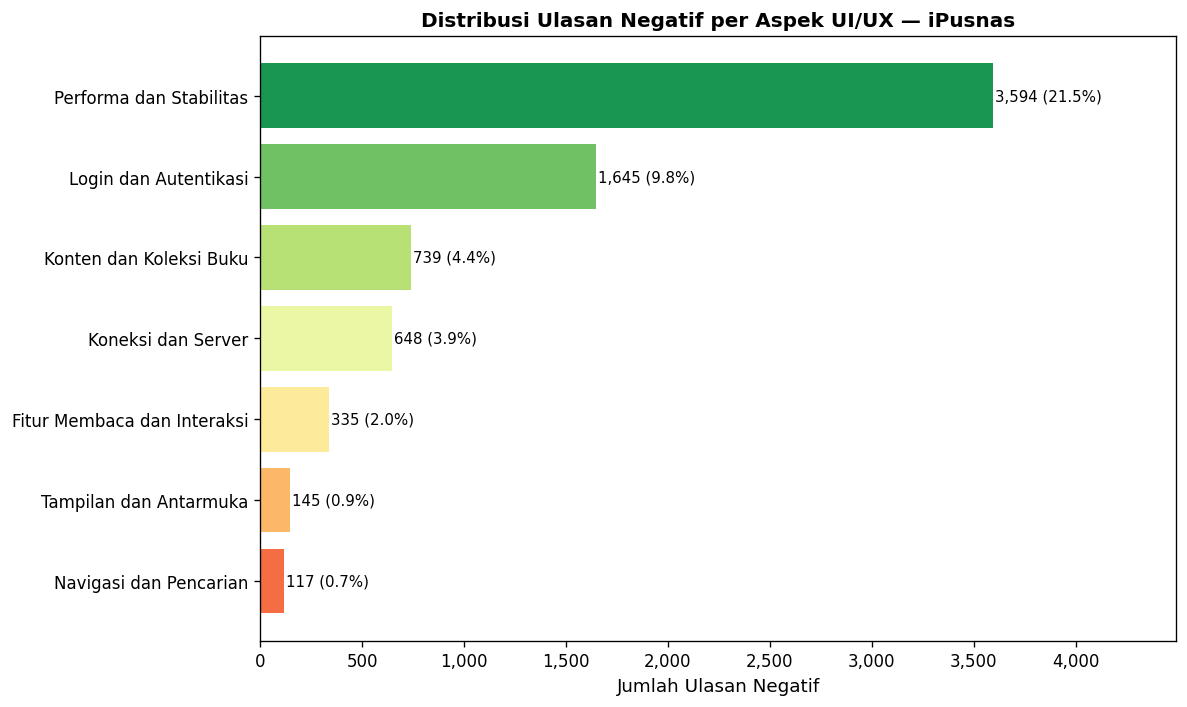

Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/distribusi_aspek_negatif.png


In [ ]:
# ── Tabel Aspek + Topik ──────────────────────────────────────────
print("PENGELOMPOKAN TOPIK KE ASPEK UI/UX")
print("=" * 72)
for aspek in sorted(df_neg[df_neg['aspek'] != 'Noise']['aspek'].unique()):
    if aspek == 'Lainnya':
        continue
    topik_list = df_neg[df_neg['aspek'] == aspek]['topic_label'].unique()
    topik_list = [t for t in topik_list if t != 'Noise']
    n_total = len(df_neg[df_neg['aspek'] == aspek])
    print(f"\n[{aspek}] — {n_total:,} ulasan")
    for t in sorted(topik_list):
        n = len(df_neg[df_neg['topic_label'] == t])
        print(f"  • {t:<50} ({n:,})")

# ── Tabel Distribusi per Aspek ────────────────────────────────────────────────
print(f"\n\n{'='*60}")
print("DISTRIBUSI ULASAN NEGATIF PER ASPEK")
print(f"{'='*60}")
print(f"  {'Aspek':<40} {'n Negatif':>10}  {'% dari Total':>12}")
print(f"  {'-'*60}")

aspek_summary = []
for aspek, grp in df_neg[~df_neg['aspek'].isin(['Noise', 'Lainnya'])].groupby('aspek'):
    n = len(grp)
    pct = n / len(df_valid) * 100
    aspek_summary.append({'aspek': aspek, 'n_negatif': n, 'pct': pct})

aspek_summary = sorted(aspek_summary, key=lambda x: x['n_negatif'], reverse=True)
for row in aspek_summary:
    print(f"  {row['aspek']:<40} {row['n_negatif']:>10,}  {row['pct']:>11.1f}%")

# ── Bar Chart per Aspek ───────────────────────────────────────────────────────
labels = [r['aspek'] for r in aspek_summary]
values = [r['n_negatif'] for r in aspek_summary]
pcts   = [r['pct'] for r in aspek_summary]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.8, len(labels)))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1])
ax.set_xlabel('Jumlah Ulasan Negatif', fontsize=11)
ax.set_title('Distribusi Ulasan Negatif per Aspek UI/UX — iPusnas',
             fontweight='bold', fontsize=12)
for bar, n, pct in zip(bars, values[::-1], pcts[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{n:,} ({pct:.1f}%)', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, max(values) * 1.25)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribusi_aspek_negatif.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Disimpan: {OUTPUT_DIR}/distribusi_aspek_negatif.png")

## Prioritisasi Topik Keluhan


In [ ]:
# Hitung total per topik dari seluruh dataset
df_valid['topic_label_neg'] = 'Tidak Relevan'
df_valid['aspek'] = 'Lainnya'

df_valid.loc[df_neg.index, 'topic_label_neg'] = df_neg['topic_label'].values
df_valid.loc[df_neg.index, 'aspek']           = df_neg['aspek'].values

# Hitung prioritisasi per topik
priority_rows = []
for topic_label in df_neg['topic_label'].unique():
    if topic_label == 'Noise':
        continue
    n_topik  = len(df_neg[df_neg['topic_label'] == topic_label])
    pct_dari_total = n_topik / len(df_valid) * 100
    aspek = df_neg[df_neg['topic_label'] == topic_label]['aspek'].mode()[0] if len(
        df_neg[df_neg['topic_label'] == topic_label]) > 0 else 'Lainnya'
    priority_rows.append({
        'topik'           : topic_label,
        'aspek'           : aspek,
        'n_negatif'       : n_topik,
        'pct_dari_total'  : round(pct_dari_total, 2),
    })

df_priority = pd.DataFrame(priority_rows).sort_values('n_negatif', ascending=False)

print("PRIORITISASI TOPIK KELUHAN")
print(f"{'='*72}")
print(f"  {'Topik':<40} {'Aspek':<30} {'n Neg':>6}  {'% Total':>7}")
print(f"  {'-'*72}")
for _, row in df_priority.iterrows():
    print(f"  {row['topik']:<40} {row['aspek']:<30} {row['n_negatif']:>6}  {row['pct_dari_total']:>6.1f}%")


PRIORITISASI TOPIK KELUHAN
  Topik                                    Aspek                           n Neg  % Total
  ------------------------------------------------------------------------
  Error saat Meminjam Buku                 Performa dan Stabilitas           798     4.8%
  Saran dan Apresiasi dengan Catatan       Lainnya                           583     3.5%
  Auto Logout / Sesi Berakhir Sendiri      Login dan Autentikasi             466     2.8%
  Aplikasi Makin Buruk Setelah Update      Performa dan Stabilitas           410     2.5%
  Gagal / Lambat Download Buku             Performa dan Stabilitas           293     1.8%
  Aplikasi Tidak Bisa Dibuka               Performa dan Stabilitas           275     1.6%
  Akun Hilang Tiba-tiba                    Login dan Autentikasi             266     1.6%
  Verifikasi Email/Password Bermasalah     Login dan Autentikasi             250     1.5%
  Masalah Server DLS                       Koneksi dan Server                228     1.4

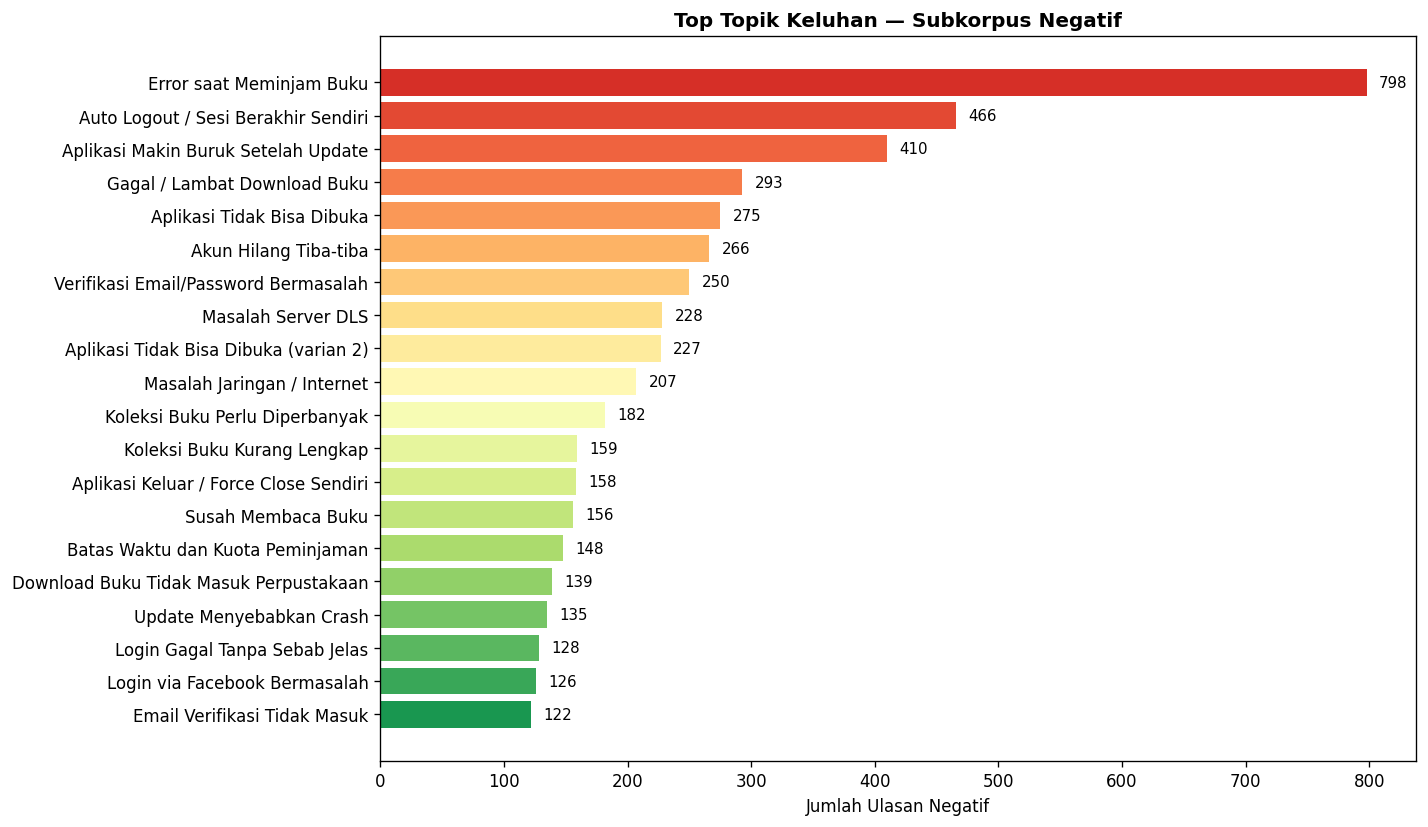

In [ ]:
df_plot = df_priority[df_priority['aspek'] != 'Lainnya'].head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(df_plot)))
bars = ax.barh(df_plot['topik'][::-1], df_plot['n_negatif'][::-1], color=colors)
ax.set_xlabel('Jumlah Ulasan Negatif')
ax.set_title('Top Topik Keluhan — Subkorpus Negatif', fontweight='bold')
for bar, n in zip(bars, df_plot['n_negatif'][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/prioritisasi_topik.png', dpi=150, bbox_inches='tight')
plt.show()


PRIORITY SCORE PER ASPEK UI/UX
  Aspek                                 n Neg   Reach   Sev    Score
  -----------------------------------------------------------------
  Performa dan Stabilitas               3,594   21.5%     4     85.9
  Login dan Autentikasi                 1,645    9.8%     4     39.3
  Konten dan Koleksi Buku                 739    4.4%     3     13.2
  Koneksi dan Server                      648    3.9%     3     11.6
  Fitur Membaca dan Interaksi             335    2.0%     2      4.0
  Navigasi dan Pencarian                  117    0.7%     2      1.4
  Tampilan dan Antarmuka                  145    0.9%     1      0.9


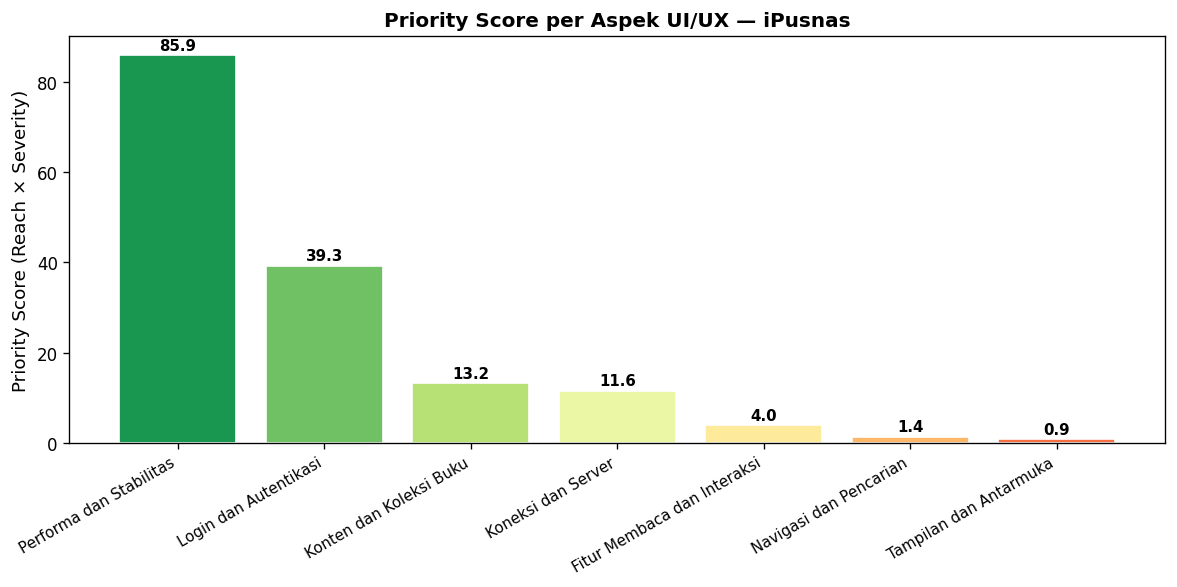

Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/priority_score_aspek.png
Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/priority_score_aspek.csv


In [ ]:
# ── Priority Score per Aspek ──────────────────────────────────────────────────
SEVERITY = {
    'Performa dan Stabilitas'     : 4,
    'Login dan Autentikasi'       : 4,
    'Konten dan Koleksi Buku'     : 3,
    'Koneksi dan Server'          : 3,
    'Fitur Membaca dan Interaksi' : 2,
    'Navigasi dan Pencarian'      : 2,
    'Tampilan dan Antarmuka'      : 1,
}

priority_rows = []
for aspek, severity in SEVERITY.items():
    n_neg  = len(df_neg[df_neg['aspek'] == aspek])
    reach  = n_neg / len(df_valid) * 100
    score  = reach * severity
    priority_rows.append({
        'aspek'         : aspek,
        'n_negatif'     : n_neg,
        'reach_pct'     : round(reach, 1),
        'severity'      : severity,
        'priority_score': round(score, 1),
    })

df_prio_aspek = pd.DataFrame(priority_rows).sort_values(
    'priority_score', ascending=False
).reset_index(drop=True)

# ── Tabel ─────────────────────────────────────────────────────────────────────
print("PRIORITY SCORE PER ASPEK UI/UX")
print("=" * 72)
print(f"  {'Aspek':<35} {'n Neg':>7}  {'Reach':>6}  {'Sev':>4}  {'Score':>7}")
print(f"  {'-'*65}")
for _, row in df_prio_aspek.iterrows():
    print(f"  {row['aspek']:<35} {row['n_negatif']:>7,}  "
          f"{row['reach_pct']:>5.1f}%  {row['severity']:>4}  {row['priority_score']:>7.1f}")

# ── Bar Chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.8, len(df_prio_aspek))
)
bars = ax.bar(
    df_prio_aspek['aspek'],
    df_prio_aspek['priority_score'],
    color=colors, edgecolor='white'
)
ax.set_ylabel('Priority Score (Reach × Severity)', fontsize=11)
ax.set_title('Priority Score per Aspek UI/UX — iPusnas',
             fontweight='bold', fontsize=12)
ax.set_xticklabels(df_prio_aspek['aspek'], rotation=30, ha='right', fontsize=9)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{h:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/priority_score_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Disimpan: {OUTPUT_DIR}/priority_score_aspek.png")

# ── Simpan ke CSV ─────────────────────────────────────────────────────────────
df_prio_aspek.to_csv(f'{OUTPUT_DIR}/priority_score_aspek.csv',
                     index=False, encoding='utf-8-sig')
print(f"Disimpan: {OUTPUT_DIR}/priority_score_aspek.csv")

## Temporal Analysis per Aspek

In [ ]:
VERSION_PERIODS = [
    ('2017-02-03', '2017-04-29', 'v1.1.6  | Feb 2017'),
    ('2017-04-30', '2019-03-04', 'v1.1.8  | Apr 2017'),
    ('2019-03-05', '2020-05-03', 'v1.4.1  | Mar 2019'),
    ('2020-05-04', '2020-10-04', 'v1.4.7  | Mei 2020'),
    ('2020-10-05', '2022-02-22', 'v1.4.8  | Okt 2020'),
    ('2022-02-23', '2023-05-11', 'Update  | Feb 2022'),
    ('2023-05-12', '2023-08-27', 'Update  | Mei 2023'),
    ('2023-08-28', '2025-02-10', 'Update  | Agt 2023'),
    ('2025-02-11', '2025-08-26', 'Update  | Feb 2025'),
    ('2025-08-27', '2026-01-28', 'Update  | Agt 2025'),
    ('2026-01-29', '2026-04-28', 'Update  | Jan 2026'),
    ('2026-04-29', '2099-12-31', 'v2.1.4  | Apr 2026'),
]
PERIOD_ORDER = [p[2] for p in VERSION_PERIODS]

def assign_period(date):
    for start, end, label in VERSION_PERIODS:
        if pd.Timestamp(start) <= date <= pd.Timestamp(end):
            return label
    return 'Unknown'

df_valid['periode'] = df_valid['at'].apply(assign_period)

print("Distribusi ulasan per periode:")
dist = df_valid['periode'].value_counts()
for p in PERIOD_ORDER:
    n = dist.get(p, 0)
    print(f"  {p:<24} {n:>5,}")


Distribusi ulasan per periode:
  v1.1.6  | Feb 2017          92
  v1.1.8  | Apr 2017       1,811
  v1.4.1  | Mar 2019       2,430
  v1.4.7  | Mei 2020         947
  v1.4.8  | Okt 2020       2,616
  Update  | Feb 2022       1,096
  Update  | Mei 2023         205
  Update  | Agt 2023       3,035
  Update  | Feb 2025         715
  Update  | Agt 2025       2,103
  Update  | Jan 2026       1,235
  v2.1.4  | Apr 2026         292


In [ ]:
df_analisis = df_valid[
    (df_valid['periode'] != 'Unknown') &
    (df_valid['aspek'] != 'Lainnya') &
    (df_valid['aspek'] != 'Noise')
].copy()

summary = (
    df_analisis
    .groupby(['periode', 'aspek', 'sentimen'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ['positif', 'negatif']:
    if col not in summary.columns:
        summary[col] = 0
summary.columns.name = None
summary = summary.rename(columns={'positif': 'Positif', 'negatif': 'Negatif'})
summary['Total']   = summary['Positif'] + summary['Negatif']
summary['pct_neg'] = (summary['Negatif'] / summary['Total'].replace(0, 1) * 100).round(1)
summary['periode'] = pd.Categorical(summary['periode'], categories=PERIOD_ORDER, ordered=True)
summary = summary.sort_values(['aspek', 'periode'])

aspek_list = [a for a in df_analisis['aspek'].unique() if a not in ('Lainnya', 'Noise')]

print("% SENTIMEN NEGATIF PER ASPEK PER PERIODE")
print("=" * 72)
for aspek in sorted(aspek_list):
    df_a = summary[summary['aspek'] == aspek][['periode','Total','pct_neg']]
    df_a = df_a[df_a['Total'] > 0]
    if df_a.empty:
        continue
    print(f"\n[{aspek}]")
    print(f"  {'Periode':<24} {'Total':>6} {'%Neg':>6}")
    print("  " + "-" * 38)
    for _, row in df_a.iterrows():
        print(f"  {str(row['periode']):<24} {int(row['Total']):>6} {row['pct_neg']:>5.1f}%")


% SENTIMEN NEGATIF PER ASPEK PER PERIODE

[Fitur Membaca dan Interaksi]
  Periode                   Total   %Neg
  --------------------------------------
  v1.4.1  | Mar 2019           50  66.0%
  v1.4.7  | Mei 2020           13  76.9%
  v1.4.8  | Okt 2020           49  91.8%
  Update  | Feb 2022           49  89.8%
  Update  | Mei 2023            5  80.0%
  Update  | Agt 2023          106  95.3%
  Update  | Feb 2025           13  92.3%
  Update  | Agt 2025           27 100.0%
  Update  | Jan 2026           16 100.0%
  v2.1.4  | Apr 2026            6  66.7%

[Koneksi dan Server]
  Periode                   Total   %Neg
  --------------------------------------
  v1.4.1  | Mar 2019           91  78.0%
  v1.4.7  | Mei 2020           64  89.1%
  v1.4.8  | Okt 2020          211  82.5%
  Update  | Feb 2022           30  86.7%
  Update  | Mei 2023            7  85.7%
  Update  | Agt 2023          122  98.4%
  Update  | Feb 2025           27 100.0%
  Update  | Agt 2025           37  94.6%
  Up

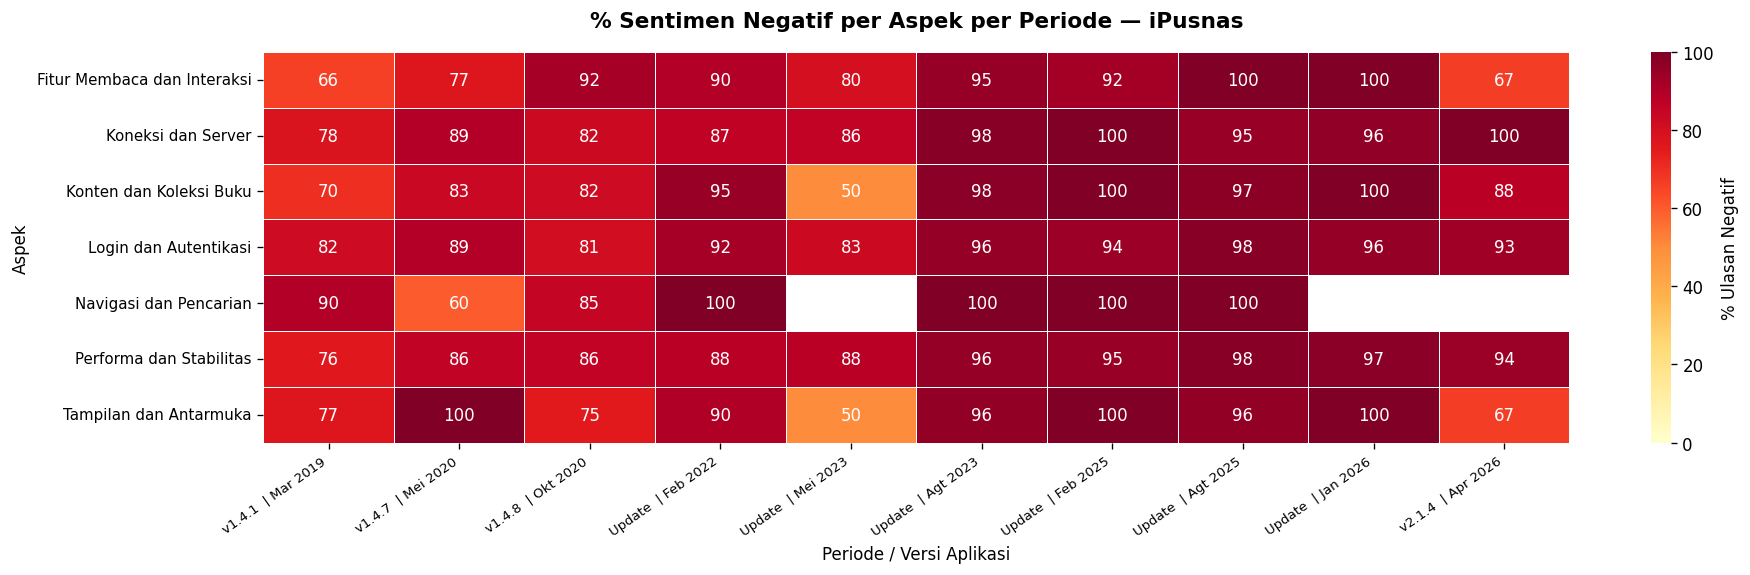

Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/heatmap_aspek_periode.png


In [ ]:
pivot = summary.pivot_table(
    index='aspek', columns='periode', values='pct_neg', aggfunc='mean'
)
pivot = pivot.reindex(columns=[p for p in PERIOD_ORDER if p in pivot.columns])

fig, ax = plt.subplots(figsize=(16, max(4, len(pivot)*0.7)))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            vmin=0, vmax=100, linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% Ulasan Negatif'}, ax=ax)
ax.set_title('% Sentimen Negatif per Aspek per Periode — iPusnas',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Periode / Versi Aplikasi', fontsize=10)
ax.set_ylabel('Aspek', fontsize=10)
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/heatmap_aspek_periode.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Disimpan: {OUTPUT_DIR}/heatmap_aspek_periode.png")


In [ ]:
# Distribusi sentimen per periode (semua ulasan, tanpa filter aspek)
sent_periode = (
    df_valid[df_valid['periode'] != 'Unknown']
    .groupby(['periode', 'sentimen'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
sent_periode.columns.name = None
sent_periode = sent_periode.rename(columns={'negatif': 'Negatif', 'positif': 'Positif'})
sent_periode['Total']   = sent_periode['Negatif'] + sent_periode['Positif']
sent_periode['pct_neg'] = (sent_periode['Negatif'] / sent_periode['Total'] * 100).round(1)
sent_periode['periode'] = pd.Categorical(sent_periode['periode'],
                                          categories=PERIOD_ORDER, ordered=True)
sent_periode = sent_periode.sort_values('periode')

print("DISTRIBUSI SENTIMEN PER PERIODE")
print("=" * 60)
print(f"  {'Periode':<24} {'Neg':>6} {'Pos':>6} {'Total':>7} {'%Neg':>6}")
print(f"  {'-'*52}")
for _, row in sent_periode.iterrows():
    print(f"  {str(row['periode']):<24} {int(row['Negatif']):>6} "
          f"{int(row['Positif']):>6} {int(row['Total']):>7} {row['pct_neg']:>5.1f}%")

DISTRIBUSI SENTIMEN PER PERIODE
  Periode                     Neg    Pos   Total   %Neg
  ----------------------------------------------------
  v1.1.6  | Feb 2017           57     35      92  62.0%
  v1.1.8  | Apr 2017         1406    405    1811  77.6%
  v1.4.1  | Mar 2019         1851    579    2430  76.2%
  v1.4.7  | Mei 2020          811    136     947  85.6%
  v1.4.8  | Okt 2020         2233    383    2616  85.4%
  Update  | Feb 2022          960    136    1096  87.6%
  Update  | Mei 2023          174     31     205  84.9%
  Update  | Agt 2023         2908    127    3035  95.8%
  Update  | Feb 2025          674     41     715  94.3%
  Update  | Agt 2025         2060     43    2103  98.0%
  Update  | Jan 2026         1192     43    1235  96.5%
  v2.1.4  | Apr 2026          277     15     292  94.9%


## Nielsen Heuristic Mapping & Rekomendasi

Pemetaan aspek ke Nielsen's 10 Usability Heuristics dilakukan secara **post-hoc**
berdasarkan topik keluhan yang ditemukan dari BERTopic.

Isi `NIELSEN` dan `REKOMENDASI` setelah labeling dan mapping aspek selesai.


In [ ]:
# ── ISI SETELAH ASPEK TERIDENTIFIKASI DARI BERTOPIC ──────────────────────────

NIELSEN = {
    'Login dan Autentikasi':
        'H1 — Visibility of System Status\n'
        '+ H9 — Help Users Recognize, Diagnose, and Recover from Errors',

    'Performa dan Stabilitas':
        'H1 — Visibility of System Status\n'
        '+ H9 — Help Users Recognize, Diagnose, and Recover from Errors',

    'Koneksi dan Server':
        'H1 — Visibility of System Status\n'
        '+ H9 — Help Users Recognize, Diagnose, and Recover from Errors',

    'Fitur Membaca dan Interaksi':
        'H7 — Flexibility and Efficiency of Use\n'
        '+ H3 — User Control and Freedom',

    'Tampilan dan Antarmuka':
        'H7 — Flexibility and Efficiency of Use\n'
        '+ H8 — Aesthetic and Minimalist Design',

    'Konten dan Koleksi Buku':
        'H2 — Match Between System and the Real World\n'
        '+ H1 — Visibility of System Status',

    'Navigasi dan Pencarian':
        'H6 — Recognition Rather Than Recall\n'
        '+ H3 — User Control and Freedom',
}

REKOMENDASI = {
    'Login dan Autentikasi':
        'Berdasarkan topik "Login via Facebook Bermasalah", '
        '"Verifikasi Email Tidak Masuk", "Login Stuck / Harap Tunggu", '
        'dan "Verifikasi Perangkat Gagal": '
        '(1) Tampilkan status proses login dan verifikasi secara real-time, '
        '(2) Tambahkan tombol kirim ulang email verifikasi beserta informasi waktu tunggu, '
        '(3) Sediakan metode login alternatif ketika autentikasi melalui Facebook atau email gagal, '
        '(4) Berikan pesan error yang spesifik beserta langkah pemulihan yang dapat dilakukan pengguna.',

    'Performa dan Stabilitas':
        'Berdasarkan topik "Aplikasi Tidak Bisa Dibuka", '
        '"Force Close", "Loading Lama", "Lag / Aplikasi Lemot Parah", '
        'dan "Error Setelah Update": '
        '(1) Tampilkan indikator loading dan progress yang jelas saat aplikasi memuat konten, '
        '(2) Sediakan tombol coba lagi (retry) ketika terjadi kegagalan proses, '
        '(3) Simpan sesi dan posisi baca pengguna secara otomatis agar tidak hilang ketika aplikasi crash, '
        '(4) Tampilkan pesan error yang spesifik agar pengguna mengetahui tindakan yang perlu dilakukan.',

    'Koneksi dan Server':
        'Berdasarkan topik "Masalah Server DLS", '
        '"Network Timeout", dan "Masalah Jaringan / Internet": '
        '(1) Tampilkan informasi yang membedakan antara gangguan server dan gangguan koneksi pengguna, '
        '(2) Sediakan halaman status layanan ketika server sedang maintenance atau mengalami gangguan, '
        '(3) Tambahkan mekanisme retry otomatis untuk proses yang gagal akibat koneksi tidak stabil, '
        '(4) Sediakan akses offline untuk buku yang telah berhasil diunduh sebelumnya.',

    'Fitur Membaca dan Interaksi':
        'Berdasarkan topik "Fitur Bookmark Tidak Berfungsi", '
        '"Scroll dan Highlight Bermasalah", "Tidak Support Landscape / Zoom", '
        'dan "Tidak Ada Notifikasi Buku Tersedia": '
        '(1) Sinkronkan bookmark dan halaman terakhir dibaca secara otomatis pada seluruh sesi membaca, '
        '(2) Tambahkan fitur zoom dan orientasi landscape untuk meningkatkan fleksibilitas membaca, '
        '(3) Berikan umpan balik visual ketika bookmark atau highlight berhasil disimpan, '
        '(4) Tambahkan fitur notifikasi otomatis ketika buku yang diantrekan sudah tersedia.',

    'Tampilan dan Antarmuka':
        'Berdasarkan topik "Permintaan Dark Mode", '
        '"Ukuran Font Terlalu Kecil", dan "Aksesibilitas untuk Tunanetra": '
        '(1) Tambahkan mode gelap (dark mode) untuk meningkatkan kenyamanan membaca dalam kondisi minim cahaya, '
        '(2) Sediakan pengaturan ukuran font, jarak baris, dan margin yang dapat disesuaikan pengguna, '
        '(3) Tingkatkan kompatibilitas dengan screen reader untuk mendukung aksesibilitas pengguna tunanetra, '
        '(4) Pastikan kontras warna dan elemen antarmuka memenuhi standar aksesibilitas digital.',

    'Konten dan Koleksi Buku':
        'Berdasarkan topik "Koleksi Buku Kurang Lengkap", '
        '"Antrian Peminjaman Terlalu Panjang", '
        '"Durasi Peminjaman Terlalu Singkat", dan "Tidak Bisa Meminjam": '
        '(1) Tambahkan indikator posisi antrian dan estimasi waktu ketersediaan buku, '
        '(2) Evaluasi kebijakan durasi serta kuota peminjaman agar lebih sesuai dengan kebutuhan pengguna, '
        '(3) Prioritaskan penambahan koleksi buku pada kategori yang paling sering diminta pengguna, '
        '(4) Tampilkan informasi kejelasan alasan ketika pengguna tidak dapat meminjam buku.',

    'Navigasi dan Pencarian':
        'Berdasarkan topik "Fitur Pencarian Bermasalah" dan '
        '"Hasil Pencarian Tidak Akurat": '
        '(1) Tambahkan fitur auto-suggestion dan auto-complete saat pengguna mengetik kata kunci, '
        '(2) Dukung pencarian parsial, sinonim, dan toleransi kesalahan pengetikan (typo), '
        '(3) Sediakan filter pencarian berdasarkan kategori, penulis, tahun terbit, dan status ketersediaan, '
        '(4) Tampilkan rekomendasi kata kunci alternatif ketika hasil pencarian tidak ditemukan.',
}

print("RINGKASAN REKOMENDASI PERBAIKAN UI/UX")
print("=" * 72)
print("(Isi NIELSEN dan REKOMENDASI dict terlebih dahulu)")

for aspek in sorted(aspek_list):
    df_a   = df_analisis[df_analisis['aspek'] == aspek]
    total  = len(df_a)
    n_neg  = (df_a['sentimen'] == 'negatif').sum()
    pct_n  = n_neg / total * 100 if total else 0
    print(f"\n{'─'*72}")
    print(f"  {aspek}")
    print(f"  {total:,} ulasan | {pct_n:.1f}% negatif")
    print(f"  Nielsen      : {NIELSEN.get(aspek, '[belum diisi]')}")
    print(f"  Rekomendasi  : {REKOMENDASI.get(aspek, '[belum diisi]')}")


RINGKASAN REKOMENDASI PERBAIKAN UI/UX
(Isi NIELSEN dan REKOMENDASI dict terlebih dahulu)

────────────────────────────────────────────────────────────────────────
  Fitur Membaca dan Interaksi
  334 ulasan | 88.6% negatif
  Nielsen      : H7 — Flexibility and Efficiency of Use
+ H3 — User Control and Freedom
  Rekomendasi  : Berdasarkan topik "Fitur Bookmark Tidak Berfungsi", "Scroll dan Highlight Bermasalah", "Tidak Support Landscape / Zoom", dan "Tidak Ada Notifikasi Buku Tersedia": (1) Sinkronkan bookmark dan halaman terakhir dibaca secara otomatis pada seluruh sesi membaca, (2) Tambahkan fitur zoom dan orientasi landscape untuk meningkatkan fleksibilitas membaca, (3) Berikan umpan balik visual ketika bookmark atau highlight berhasil disimpan, (4) Tambahkan fitur notifikasi otomatis ketika buku yang diantrekan sudah tersedia.

────────────────────────────────────────────────────────────────────────
  Koneksi dan Server
  648 ulasan | 88.4% negatif
  Nielsen      : H1 — Visibility of

## Validasi Manual Sampel

Ekspor sampel stratified dari subkorpus negatif untuk validasi manual:
verifikasi apakah label topik yang diberikan sudah sesuai dengan isi ulasan.


In [ ]:
VALIDASI_PATH = f'{OUTPUT_DIR}/validasi_topik_negatif.csv'
N_PER_TOPIC   = 20

sample_parts = []
for topik in df_neg['topic_label'].unique():
    if topik == 'Noise':
        continue
    df_t = df_neg[df_neg['topic_label'] == topik]
    n    = min(N_PER_TOPIC, len(df_t))
    sample_parts.append(df_t.sample(n, random_state=42))

if sample_parts:
    df_val = pd.concat(sample_parts).reset_index(drop=True)
    df_val['label_manual'] = ''  # kolom kosong untuk validasi
    df_val[['ulasan', 'rating', 'sentimen', 'confidence',
            'topic_id', 'topic_label', 'aspek', 'label_manual']
           ].to_csv(VALIDASI_PATH, index=False, encoding='utf-8-sig')
    print(f"Sampel validasi: {len(df_val):,} ulasan dari {df_val['topic_label'].nunique()} topik")
    print(f"Disimpan: {VALIDASI_PATH}")
    print("\nIsi kolom 'label_manual' untuk verifikasi kecocokan topik.")


Sampel validasi: 1,700 ulasan dari 85 topik
Disimpan: /content/drive/MyDrive/skripsi/nested_bertopic/output/validasi_topik_negatif.csv

Isi kolom 'label_manual' untuk verifikasi kecocokan topik.


In [ ]:
# 1. Cek isi df_neg sekarang
print("=== df_neg topic_label sample ===")
print(df_neg['topic_label'].value_counts())

print("\n=== df_neg aspek sample ===")
print(df_neg['aspek'].value_counts())

# 2. Cek mapping
print("\n=== Cek mapping ===")
mapped = df_neg['topic_label'].map(TOPIC_TO_ASPEK)
print("Tidak ter-mapping:", mapped.isna().sum())
print("Ter-mapping:", mapped.notna().sum())

# 3. Cek isi file validasi
print("\n=== Isi file validasi ===")
df_check = pd.read_csv(VALIDASI_PATH)
print(df_check['aspek'].value_counts())
print(df_check['topic_label'].value_counts())


=== df_neg topic_label sample ===
topic_label
Noise                                  6012
Error saat Meminjam Buku                798
Saran dan Apresiasi dengan Catatan      583
Auto Logout / Sesi Berakhir Sendiri     466
Aplikasi Makin Buruk Setelah Update     410
                                       ... 
Verifikasi Perangkat Gagal               21
Permintaan Perbaikan Segera              21
Tidak Support Landscape / Zoom           21
Aplikasi Sering Keluar Sendiri           20
Error saat Dibuka                        20
Name: count, Length: 86, dtype: int64

=== df_neg aspek sample ===
aspek
Noise                          6012
Performa dan Stabilitas        3594
Login dan Autentikasi          1645
Lainnya                        1490
Konten dan Koleksi Buku         739
Koneksi dan Server              648
Fitur Membaca dan Interaksi     335
Tampilan dan Antarmuka          145
Navigasi dan Pencarian          117
Name: count, dtype: int64

=== Cek mapping ===
Tidak ter-mapping: 28
Ter-

In [ ]:
# Lihat label aktual di df_neg
print(df_neg['topic_label'].unique())


['Error saat Meminjam Buku' 'Masalah Versi Aplikasi di Play Store' 'Noise'
 'Verifikasi Perangkat Gagal' 'Kritik Perpustakaan Nasional'
 'Apresiasi Literasi Indonesia' 'Batas Waktu dan Kuota Peminjaman'
 'Tidak Bisa Masuk Akun' 'Apresiasi Aplikasi'
 'Error Berulang pada Aplikasi' 'Download Buku Tidak Masuk Perpustakaan'
 'Saran dan Apresiasi dengan Catatan' 'Aplikasi Sering Error (Varian)'
 'Performa Memburuk Setelah Update' 'Auto Logout / Sesi Berakhir Sendiri'
 'Bintang Kondisional' 'Loading Lama' 'Akun Hilang Tiba-tiba'
 'Buku Tidak Bisa Diunduh' 'Perbandingan dengan Perangkat Lain'
 'Susah Membaca Buku' 'Error Berlangsung Berhari-hari'
 'Sering Error saat Mendaftar' 'Aplikasi Makin Buruk Setelah Update'
 'Error saat Meminjam (Varian)' 'Sering Error'
 'Kritik Kualitas Aplikasi Pemerintah' 'Error Meski Menggunakan WiFi'
 'Aplikasi Tidak Bisa Dibuka (varian 2)'
 'Permintaan Perbaikan Fitur Pinjam' 'Aplikasi Tidak Bisa Dibuka'
 'Banyak Bug / Butuh Maintenance'
 'Tidak Support Tablet / 

In [ ]:
# Cek berapa yang berhasil di-mapping
mapped = df_neg['topic_label'].map(TOPIC_TO_ASPEK)
print("Tidak ter-mapping:", mapped.isna().sum())
print("Ter-mapping:", mapped.notna().sum())
print("\nLabel yang tidak ter-mapping:")
print(df_neg[mapped.isna()]['topic_label'].value_counts())

Tidak ter-mapping: 28
Ter-mapping: 14697

Label yang tidak ter-mapping:
topic_label
Kritik Kualitas Pemerintah (Varian)    28
Name: count, dtype: int64


## Simpan Semua Output ke Drive

In [ ]:
# Gabungkan df_neg dan df_pos kembali ke df_valid
df_valid.loc[df_neg.index, 'topic_id']    = df_neg['topic_id'].values
df_valid.loc[df_neg.index, 'topic_label'] = df_neg['topic_label'].values

df_valid.loc[df_pos.index, 'topic_id']    = df_pos['topic_id'].values
df_valid.loc[df_pos.index, 'topic_label'] = df_pos['topic_label'].values

# Simpan
FINAL_PATH   = f'{OUTPUT_DIR}/df_final_nested.csv'
SUMMARY_PATH = f'{OUTPUT_DIR}/summary_aspek_periode.csv'
PRIORITY_PATH = f'{OUTPUT_DIR}/prioritisasi_topik.csv'
NIELSEN_PATH  = f'{OUTPUT_DIR}/nielsen_rekomendasi.csv'

save_cols = ['ulasan', 'rating', 'at', 'appVersion', 'cleaned',
             'sentimen', 'confidence', 'topic_id', 'topic_label',
             'aspek', 'periode']
df_final = df_valid[[c for c in save_cols if c in df_valid.columns]].copy()
df_final.to_csv(FINAL_PATH, index=False, encoding='utf-8-sig')
summary.to_csv(SUMMARY_PATH, index=False, encoding='utf-8-sig')
df_priority.to_csv(PRIORITY_PATH, index=False, encoding='utf-8-sig')

# Nielsen rekomendasi
nielsen_rows = []
for aspek in sorted(aspek_list):
    df_a  = df_analisis[df_analisis['aspek'] == aspek]
    total = len(df_a)
    n_neg = (df_a['sentimen'] == 'negatif').sum()
    pct_n = n_neg / total * 100 if total else 0
    nielsen_rows.append({
        'aspek'       : aspek,
        'total_ulasan': total,
        'pct_negatif' : round(pct_n, 1),
        'nielsen'     : NIELSEN.get(aspek, ''),
        'rekomendasi' : REKOMENDASI.get(aspek, ''),
    })
pd.DataFrame(nielsen_rows).to_csv(NIELSEN_PATH, index=False, encoding='utf-8-sig')

print("Output tersimpan ke Drive:")
print(f"  [1] df_final_nested.csv          — {len(df_final):,} ulasan + topik + aspek")
print(f"  [2] summary_aspek_periode.csv    — tren per aspek × periode")
print(f"  [3] prioritisasi_topik.csv       — ranking topik berdasarkan volume")
print(f"  [4] nielsen_rekomendasi.csv      — mapping Nielsen + rekomendasi")
print(f"  [5] sentiment_full.csv           — cache sentimen IndoBERT")
print(f"  [6] heatmap_aspek_periode.png    — heatmap % negatif per periode")
print(f"  [7] distribusi_sentimen.png      — distribusi sentimen keseluruhan")
print(f"  [8] prioritisasi_topik.png       — bar chart prioritas topik")
print(f"  [9] bertopic_negatif/            — model BERTopic subkorpus negatif")
print(f" [10] bertopic_positif/            — model BERTopic subkorpus positif")
print(f"\nSelesai.")


Output tersimpan ke Drive:
  [1] df_final_nested.csv          — 16,733 ulasan + topik + aspek
  [2] summary_aspek_periode.csv    — tren per aspek × periode
  [3] prioritisasi_topik.csv       — ranking topik berdasarkan volume
  [4] nielsen_rekomendasi.csv      — mapping Nielsen + rekomendasi
  [5] sentiment_full.csv           — cache sentimen IndoBERT
  [6] heatmap_aspek_periode.png    — heatmap % negatif per periode
  [7] distribusi_sentimen.png      — distribusi sentimen keseluruhan
  [8] prioritisasi_topik.png       — bar chart prioritas topik
  [9] bertopic_negatif/            — model BERTopic subkorpus negatif
 [10] bertopic_positif/            — model BERTopic subkorpus positif

Selesai.
